In [2]:
# ── CELL 1: Imports ───────────────────────────────────────────────────────────
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import circadapt
from circadapt.error import ModelCrashed, ModelNotStable

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

MMHG_TO_PA  = 133.322
LPM_TO_M3PS = 1.0 / 60000.0

In [3]:
# ── CELL 2: Load and standardize data ────────────────────────────────────────
DATA_PATH = Path("SAS Database_multiple populations_for Amee Sangani.xlsx")

def standardize_column_name(col):
    col = str(col).strip()
    for old, new in [("%","pct"),("/","_per_"),("+","_plus"),("-","_minus"), ("(","_"),(")","\"")]:
        col = col.replace(old, new)
    col = re.sub(r"[^\w\s\.]+", "", col)
    col = re.sub(r"\s+", "_", col)
    col = re.sub(r"_+", "_", col)
    return col.strip("_").lower()

raw_df = pd.read_excel(DATA_PATH, sheet_name=0)
raw_df.columns = [standardize_column_name(c) for c in raw_df.columns]
print(f"Loaded: {raw_df.shape[0]} rows × {raw_df.shape[1]} columns")

Loaded: 350 rows × 110 columns


In [4]:
# ── CELL 3: Build model_df ────────────────────────────────────────────────────
df = raw_df.copy()

df["patient_id"] = (df["study"].astype(str).str.strip() + "_" +
                    df["subjectid"].astype(str).str.strip())

df["co_final"] = df["co_swan"]
mask = df["co_final"].isna() & df["co"].notna()
df.loc[mask, "co_final"] = df.loc[mask, "co"]

df["condition_label"] = df["condition_description"].astype(str).str.strip().str.lower()
df["is_rest"] = df["condition_label"].str.contains("rest", na=False)

model_df = pd.DataFrame({
    "patient_id" : df["patient_id"],
    "condition"  : df["condition_label"],
    "is_rest"    : df["is_rest"],
    "hr_bpm"     : df["hr"],
    "co_l_min"   : df["co_final"],
    "map_mmhg"   : df["map"],
    "ef_pct"     : df["ef"],
    "edv_ml"     : df["edv"],
    "esv_ml"     : df["esv"],
    "pcwp_mmhg"  : df["pcwp"],
    "sbp_mmhg"   : df["sbp"],
    "dbp_mmhg"   : df["dbp"],
    "rap_mmhg"   : df["rap"],
    "mpap_mmhg"  : df["mpap"],
    "age"        : df["age"],
    "sex"        : df["sex"],
    "bsa"        : df["bsa"],
})

# Force numeric types — raw Excel uses '.' as missing placeholder
numeric_cols = ["hr_bpm","co_l_min","map_mmhg","sbp_mmhg","dbp_mmhg",
                "edv_ml","esv_ml","ef_pct","pcwp_mmhg","rap_mmhg","mpap_mmhg",
                "age","bsa"]
for col in numeric_cols:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df["usable_for_fit"] = (
    model_df["hr_bpm"].notna()   &
    model_df["co_l_min"].notna() &
    model_df["map_mmhg"].notna() &
    model_df["ef_pct"].notna()   &
    model_df["edv_ml"].notna()   &
    model_df["esv_ml"].notna()
)

print(f"model_df: {len(model_df)} rows, {model_df['patient_id'].nunique()} patients")
print(f"Usable for fit: {model_df['usable_for_fit'].sum()}")

model_df: 350 rows, 44 patients
Usable for fit: 145


In [5]:
# ── CELL 4: Build clean rest_df ───────────────────────────────────────────────
rest_df = model_df[model_df["is_rest"] & model_df["usable_for_fit"]].copy()

rest_df = rest_df[
    (rest_df["edv_ml"] > 0) & (rest_df["esv_ml"] > 0) &
    (rest_df["edv_ml"] > rest_df["esv_ml"]) &
    (rest_df["hr_bpm"]   >= 30)  & (rest_df["hr_bpm"]   <= 200) &
    (rest_df["co_l_min"] >= 1.0) & (rest_df["co_l_min"] <= 12.0) &
    (rest_df["map_mmhg"] >= 40)  & (rest_df["map_mmhg"] <= 180) &
    (rest_df["edv_ml"]   <= 500) & (rest_df["esv_ml"]   <= 400) &
    (rest_df["ef_pct"]   >= 10)  & (rest_df["ef_pct"]   <= 95)
].copy()

# Exclude LVAD — not modelable with VanOsta2024
rest_df_clean = rest_df[
    ~rest_df["patient_id"].str.contains("LVAD", case=False)
].copy()

print(f"rest_df:       {len(rest_df)} rows, {rest_df['patient_id'].nunique()} patients")
print(f"rest_df_clean: {len(rest_df_clean)} rows, {rest_df_clean['patient_id'].nunique()} patients")
print(rest_df_clean["condition"].value_counts())

rest_df:       77 rows, 30 patients
rest_df_clean: 60 rows, 21 patients
condition
supine rest                       15
upright rest                      12
invasive_normoxia_supine_rest      5
invasive_normoxia_upright_rest     5
invasive_rest_fio21                5
invasive_rest_fio17                5
invasive_rest_fio15                5
invasive_upright_rest_fio12        5
invasive_rest_fio12                3
Name: count, dtype: int64


In [5]:
# ── CELL 5: CircAdapt interface ───────────────────────────────────────────────

def run_model_safe(model, n_beats=5):
    try:
        model.run(n_beats)
        return model, True, None
    except ModelCrashed:
        return model, False, "ModelCrashed"
    except ModelNotStable:
        return model, False, "ModelNotStable"
    except Exception as e:
        return model, False, f"{type(e).__name__}: {e}"

def get_theta(model):
    return {
        "Am_LV"     : float(model.get("Model.Peri.TriSeg.wLv.pLv0.Am_ref")),
        "Sf_pas_LV" : float(model.get("Model.Peri.TriSeg.wLv.pLv0.Sf_pas")),
        "Sf_act_LV" : float(model.get("Model.Peri.TriSeg.wLv.pLv0.Sf_act")),
        "Vw_LV"     : float(model.get("Model.Peri.TriSeg.wLv.V_wall")),
        "p0_PVR"    : float(model.get("Model.PFC.p0")),
    }

def set_theta(model, theta):
    model.set("Model.Peri.TriSeg.wLv.pLv0.Am_ref", float(theta["Am_LV"]))
    model.set("Model.Peri.TriSeg.wLv.pLv0.Sf_pas", float(theta["Sf_pas_LV"]))
    model.set("Model.Peri.TriSeg.wLv.pLv0.Sf_act", float(theta["Sf_act_LV"]))
    model.set("Model.Peri.TriSeg.wLv.V_wall",       float(theta["Vw_LV"]))
    model.set("Model.PFC.p0",                        float(theta["p0_PVR"]))
    return model

def set_pinned_inputs(model, hr_bpm=None, co_l_min=None):
    if co_l_min is not None and pd.notna(co_l_min):
        model.set("Model.PFC.q0", float(co_l_min) * LPM_TO_M3PS)
        model['PFC']['is_active'] = True
    if hr_bpm is not None and pd.notna(hr_bpm):
        model['General']['t_cycle'] = 60.0 / float(hr_bpm)
    return model

def extract_outputs(model):
    v_lv    = model['Cavity']['V'][:, 'cLv']
    p_syart = model['Cavity']['p'][:, 'SyArt']
    p_la    = model['Cavity']['p'][:, 'La']
    q_sy    = model['ArtVen']['q'][:, 'CiSy']
    edv_ml  = float(np.max(v_lv)  * 1e6)
    esv_ml  = float(np.min(v_lv)  * 1e6)
    ef_pct  = float((edv_ml - esv_ml) / edv_ml * 100.0) if edv_ml > 0 else np.nan
    return {
        "map_mmhg" : float(np.mean(p_syart) / MMHG_TO_PA),
        "sbp_mmhg" : float(np.max(p_syart)  / MMHG_TO_PA),
        "dbp_mmhg" : float(np.min(p_syart)  / MMHG_TO_PA),
        "co_l_min" : float(np.mean(np.abs(q_sy)) * 60000.0),
        "edv_ml"   : edv_ml,
        "esv_ml"   : esv_ml,
        "ef_pct"   : ef_pct,
        "pcwp_mmhg": float(np.mean(p_la) / MMHG_TO_PA),
    }

# Build clean base snapshot — PFC inactive before export
_BASE_MODEL = circadapt.VanOsta2024()
_BASE_MODEL.run(stable=True)
_BASE_MODEL['PFC']['is_active'] = False
_BASE_STATE = _BASE_MODEL.model_export()
_DEFAULT_THETA = get_theta(_BASE_MODEL)

# Verify snapshot is clean
_m_verify = circadapt.VanOsta2024()
_m_verify.model_import(_BASE_STATE)
_m_verify, _ok, _err = run_model_safe(_m_verify, n_beats=5)
print(f"Snapshot verify: ok={_ok}  err={_err}")
print(f"Default theta:   {_DEFAULT_THETA}")

def reset_model():
    """Always return a fresh model object from clean snapshot."""
    m = circadapt.VanOsta2024()
    m.model_import(_BASE_STATE)
    return m

def simulate_with_theta(row, theta, n_beats=5):
    m = reset_model()
    m = set_theta(m, theta)
    m = set_pinned_inputs(m,
                          hr_bpm=row.get("hr_bpm"),
                          co_l_min=row.get("co_l_min"))
    m, ok, err = run_model_safe(m, n_beats=n_beats)
    if not ok:
        return None, False, err
    try:
        return extract_outputs(m), True, None
    except Exception as e:
        return None, False, f"extract_failed: {e}"

def simulate_row_final(row, theta):
    return simulate_with_theta(row, theta, n_beats=10)

# Timing test
import time
t0 = time.time()
s, ok, err = simulate_with_theta(rest_df_clean.iloc[0], _DEFAULT_THETA)
print(f"\nTiming test: ok={ok}  err={err}  time={time.time()-t0:.2f}s")
print(s)

Snapshot verify: ok=True  err=None
Default theta:   {'Am_LV': 0.00966859, 'Sf_pas_LV': 731.24545453, 'Sf_act_LV': 120000.0, 'Vw_LV': 7.35720515e-05, 'p0_PVR': 12200.0}

Timing test: ok=True  err=None  time=0.17s
{'map_mmhg': 92.06276824351472, 'sbp_mmhg': 124.07291778396082, 'dbp_mmhg': 66.89472965606194, 'co_l_min': 5.915127259911009, 'edv_ml': 136.1877074624412, 'esv_ml': 47.12187570094367, 'ef_pct': 65.39931791278647, 'pcwp_mmhg': 10.267546878832649}


In [6]:
# ── CELL 6: Fitting functions ─────────────────────────────────────────────────
THETA_BOUNDS = {
    "Am_LV"     : (0.002,  0.030),
    "Sf_pas_LV" : (200,    8000),
    "Sf_act_LV" : (5000,   400000),
    "Vw_LV"     : (0.00005, 0.0006),
    "p0_PVR"    : (3000,   40000),
}

def inputs_are_valid(row):
    hr   = row.get("hr_bpm")
    co   = row.get("co_l_min")
    map_ = row.get("map_mmhg")
    pid  = str(row.get("patient_id", ""))

    if pd.isna(hr)   or not (30  <= float(hr)   <= 200): return False, f"hr={hr}"
    if pd.isna(map_) or not (40  <= float(map_)  <= 180): return False, f"map={map_}"
    if pd.isna(co):  return False, "co is NaN"

    co_max = 14.0 if "hypoxia" in pid.lower() else 12.0
    if not (1.0 <= float(co) <= co_max):
        return False, f"co={co:.2f} outside [1,{co_max}]"
    return True, None

def fit_patient(row, n_outer=4, n_inner=6, verbose=False):
    obs = {k: row.get(k) for k in
           ["map_mmhg","edv_ml","esv_ml","ef_pct","pcwp_mmhg","co_l_min"]}

    theta = _DEFAULT_THETA.copy()

    has = {k: pd.notna(obs[k]) and float(obs[k]) > 0
           for k in ["map_mmhg","edv_ml","esv_ml","ef_pct"]}
    has["pcwp"] = (pd.notna(obs.get("pcwp_mmhg")) and
                   float(obs.get("pcwp_mmhg") or 0) >= 0)

    def safe_sim():
        s, ok, _ = simulate_with_theta(row, theta)
        return s if ok else None

    def do_pass(param, target, exp):
        for _ in range(n_inner):
            s = safe_sim()
            if s is None: return False
            if s[target] > 0:
                theta[param] *= (float(obs[target]) / s[target]) ** exp
            if param in THETA_BOUNDS:
                lo, hi = THETA_BOUNDS[param]
                theta[param] = float(np.clip(theta[param], lo, hi))
        return True

    if has["map_mmhg"]: do_pass("p0_PVR", "map_mmhg", 1.0)

    loss_history = []
    for outer in range(n_outer):
        if has["edv_ml"]:                    do_pass("Am_LV",     "edv_ml", 0.5)
        if has["ef_pct"]:                     do_pass("Sf_act_LV", "ef_pct", 0.5)
        if has["esv_ml"] and has["edv_ml"]:   do_pass("Vw_LV",     "esv_ml", 0.3)

        s = safe_sim()
        if s:
            loss = sum(
                ((s[k] - float(obs[k])) / max(float(obs[k]), 1)) ** 2
                for k in ["map_mmhg","edv_ml","esv_ml","ef_pct"] if has.get(k)
            )
            loss_history.append(loss)
            if verbose:
                print(f"  outer {outer+1}/{n_outer}  loss={loss:.4f}"
                      f"  MAP={s['map_mmhg']:.1f}  EDV={s['edv_ml']:.1f}"
                      f"  ESV={s['esv_ml']:.1f}  EF={s['ef_pct']:.1f}")

    if has["pcwp"] and float(obs.get("pcwp_mmhg") or 0) > 2:
        do_pass("Sf_pas_LV", "pcwp_mmhg", 0.4)

    sim_final, ok, _ = simulate_row_final(row, theta)
    if not ok or sim_final is None:
        return theta, {}, False, loss_history

    errors = [abs(sim_final[k] - float(obs[k])) / max(float(obs[k]), 1)
              for k in ["map_mmhg","edv_ml","ef_pct"] if has.get(k)]
    return theta, sim_final, all(e < 0.05 for e in errors), loss_history

In [7]:
# ── CELL 7: Smoke test ────────────────────────────────────────────────────────
row0 = rest_df_clean.iloc[0]
theta_t, sim_t, conv_t, lh_t = fit_patient(row0, n_outer=2, n_inner=3, verbose=True)
print(f"\nConverged: {conv_t}")
if sim_t:
    print(f"\n{'Metric':<14} {'Observed':>10} {'Simulated':>10} {'Error':>10}")
    print("-" * 48)
    for k in ["map_mmhg","co_l_min","edv_ml","esv_ml","ef_pct","pcwp_mmhg"]:
        o = row0.get(k, float("nan"))
        s = sim_t.get(k, float("nan"))
        print(f"  {k:<12} {float(o):>10.2f} {float(s):>10.2f} {float(s)-float(o):>10.2f}")
else:
    print("Smoke test failed — check Cell 5 output")

  outer 1/2  loss=0.0075  MAP=101.7  EDV=173.0  ESV=82.3  EF=52.4
  outer 2/2  loss=0.0068  MAP=101.7  EDV=173.6  ESV=82.6  EF=52.4

Converged: True

Metric           Observed  Simulated      Error
------------------------------------------------
  map_mmhg          99.67      98.76      -0.91
  co_l_min           5.65       5.64      -0.01
  edv_ml           175.33     171.34      -4.00
  esv_ml            89.67      80.73      -8.94
  ef_pct            53.00      52.88      -0.12
  pcwp_mmhg           nan       9.92        nan


In [8]:
# ── CELL 8: Cohort-wide fitting loop ─────────────────────────────────────────
results2, skipped2, failed2 = [], [], []

print(f"Fitting {len(rest_df_clean)} rows across {rest_df_clean['patient_id'].nunique()} patients...\n")

for idx, row in tqdm(rest_df_clean.iterrows(), total=len(rest_df_clean)):
    pid = row["patient_id"]

    valid, reason = inputs_are_valid(row)
    if not valid:
        skipped2.append({"patient_id": pid, "reason": reason}); continue

    theta, sim_fit, converged, loss_hist = fit_patient(row, n_outer=4, n_inner=6)

    if not sim_fit:
        failed2.append({
            "patient_id": pid,
            "group": ("HFrEF" if "hfref" in pid.lower()
                      else "hypoxia" if "hypoxia" in pid.lower() else "other"),
            "hr": row["hr_bpm"], "co": row["co_l_min"],
            "ef": row["ef_pct"],
        }); continue

    results2.append({
        "patient_id": pid, "condition": row["condition"], "converged": converged,
        "final_loss": loss_hist[-1] if loss_hist else float("nan"),
        "obs_map":  row["map_mmhg"],  "sim_map":  sim_fit["map_mmhg"],
        "obs_co":   row["co_l_min"],  "sim_co":   sim_fit["co_l_min"],
        "obs_edv":  row["edv_ml"],    "sim_edv":  sim_fit["edv_ml"],
        "obs_esv":  row["esv_ml"],    "sim_esv":  sim_fit["esv_ml"],
        "obs_ef":   row["ef_pct"],    "sim_ef":   sim_fit["ef_pct"],
        "obs_pcwp": row["pcwp_mmhg"], "sim_pcwp": sim_fit["pcwp_mmhg"],
        "theta_Am_LV":     theta["Am_LV"],
        "theta_Sf_pas_LV": theta["Sf_pas_LV"],
        "theta_Sf_act_LV": theta["Sf_act_LV"],
        "theta_Vw_LV":     theta["Vw_LV"],
        "theta_p0_PVR":    theta["p0_PVR"],
    })

    if len(results2) % 10 == 0:
        pd.DataFrame(results2).to_csv("fitting_results_checkpoint.csv", index=False)
        tqdm.write(f"  checkpoint saved ({len(results2)} rows done)")

results2_df = pd.DataFrame(results2)
results2_df.to_csv("fitting_results_clean.csv", index=False)

print(f"\nFitted:    {len(results2_df)}")
print(f"Converged: {results2_df['converged'].sum() if len(results2_df) else 0}")
print(f"Skipped:   {len(skipped2)}")
print(f"Failed:    {len(failed2)}")
if failed2:
    fdf = pd.DataFrame(failed2)
    print("\nFailed by group:")
    print(fdf["group"].value_counts())

Fitting 60 rows across 21 patients...



  0%|          | 0/60 [00:00<?, ?it/s]

  checkpoint saved (10 rows done)
  checkpoint saved (20 rows done)
  checkpoint saved (30 rows done)
  checkpoint saved (40 rows done)
  checkpoint saved (50 rows done)

Fitted:    58
Converged: 5
Skipped:   0
Failed:    2

Failed by group:
group
other      1
hypoxia    1
Name: count, dtype: int64



Metric              N     RMSE
--------------------------------
  MAP (mmHg)       58     5.16
  CO (L/min)       58     0.59
  EDV (mL)         58    32.46
  ESV (mL)         58    23.06
  EF (%)           58     8.28
  PCWP (mmHg)      19    31.03

Convergence: 8.6%

By condition:
                                sum  count
condition                                 
invasive_normoxia_supine_rest     0      5
invasive_normoxia_upright_rest    0      5
invasive_rest_fio12               0      3
invasive_rest_fio15               0      4
invasive_rest_fio17               1      5
invasive_rest_fio21               0      5
invasive_upright_rest_fio12       0      5
supine rest                       2     14
upright rest                      2     12


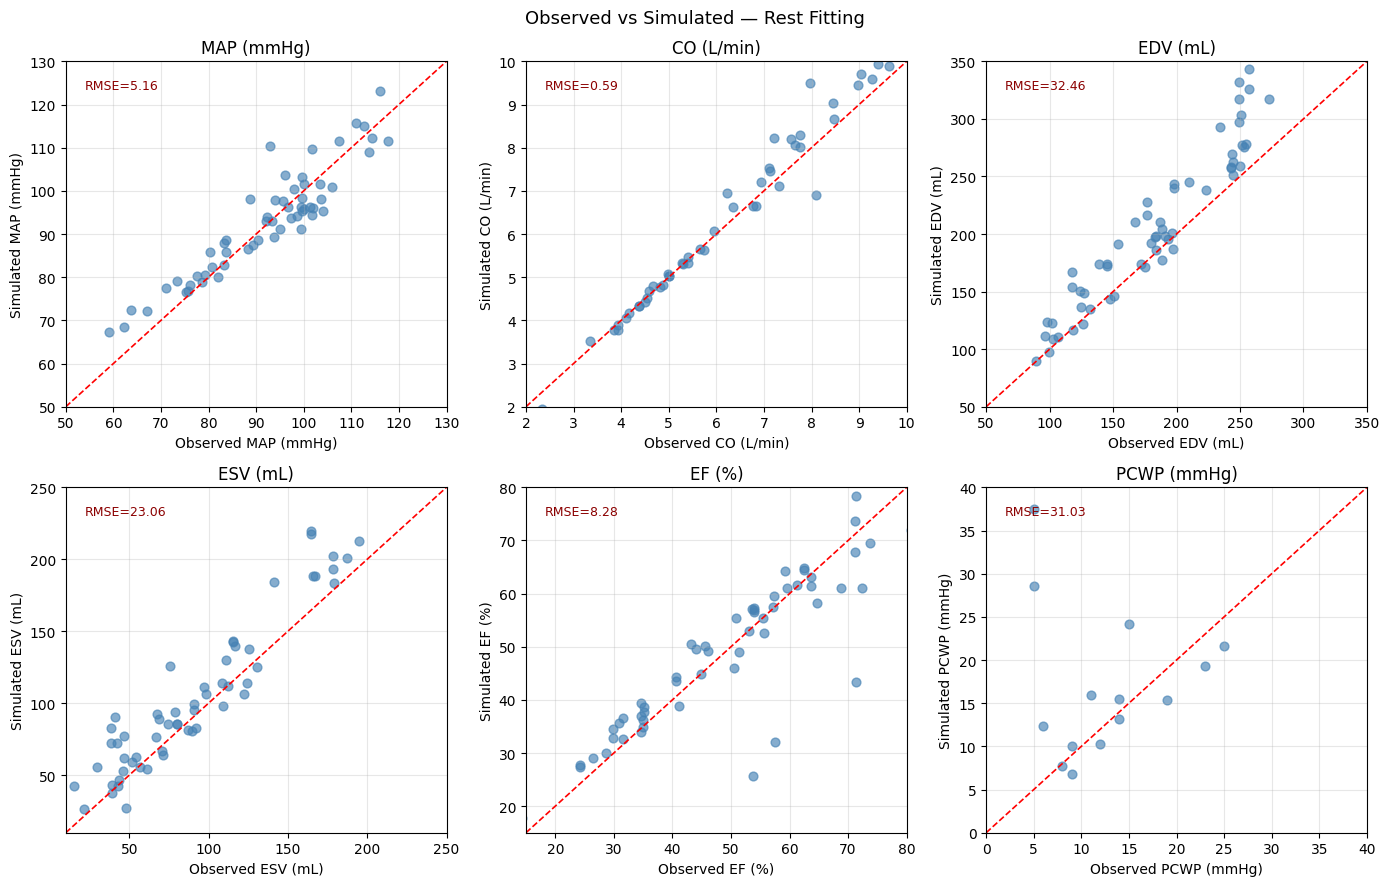

In [9]:
# ── CELL 9: RMSE summary + scatter plots ─────────────────────────────────────
def rmse(a, b):
    mask = pd.notna(a) & pd.notna(b)
    return float(np.sqrt(np.mean((b[mask] - a[mask]) ** 2))) if mask.sum() else float("nan")

print(f"\n{'Metric':<16} {'N':>4} {'RMSE':>8}")
print("-" * 32)
for label, oc, sc in [
    ("MAP (mmHg)",  "obs_map",  "sim_map"),
    ("CO (L/min)",  "obs_co",   "sim_co"),
    ("EDV (mL)",    "obs_edv",  "sim_edv"),
    ("ESV (mL)",    "obs_esv",  "sim_esv"),
    ("EF (%)",      "obs_ef",   "sim_ef"),
    ("PCWP (mmHg)", "obs_pcwp", "sim_pcwp"),
]:
    n = (pd.notna(results2_df[oc]) & pd.notna(results2_df[sc])).sum()
    r = rmse(results2_df[oc], results2_df[sc])
    print(f"  {label:<14} {n:>4} {r:>8.2f}")

print(f"\nConvergence: {results2_df['converged'].mean()*100:.1f}%")
print(f"\nBy condition:")
print(results2_df.groupby("condition")["converged"].agg(["sum","count"]))

# Scatter plots
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
specs = [
    ("MAP (mmHg)",  "obs_map",  "sim_map",  [50, 130]),
    ("CO (L/min)",  "obs_co",   "sim_co",   [2,  10]),
    ("EDV (mL)",    "obs_edv",  "sim_edv",  [50, 350]),
    ("ESV (mL)",    "obs_esv",  "sim_esv",  [10, 250]),
    ("EF (%)",      "obs_ef",   "sim_ef",   [15, 80]),
    ("PCWP (mmHg)", "obs_pcwp", "sim_pcwp", [0,  40]),
]
for ax, (label, oc, sc, lim) in zip(axes.flatten(), specs):
    sub = results2_df[[oc, sc]].dropna()
    ax.scatter(sub[oc], sub[sc], alpha=0.65, s=40, color="steelblue")
    ax.plot(lim, lim, "r--", lw=1.2)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"Observed {label}")
    ax.set_ylabel(f"Simulated {label}")
    ax.set_title(label); ax.grid(True, alpha=0.3)
    r = rmse(sub[oc], sub[sc])
    ax.text(0.05, 0.92, f"RMSE={r:.2f}", transform=ax.transAxes,
            fontsize=9, color="darkred")
fig.suptitle("Observed vs Simulated — Rest Fitting", fontsize=13)
plt.tight_layout()
plt.savefig("fitting_scatter.png", dpi=150)
plt.show()

In [10]:
# Per-metric error distribution
for k, ok, sk in [("MAP","obs_map","sim_map"),("EDV","obs_edv","sim_edv"),("EF","obs_ef","sim_ef")]:
    err = (results2_df[sk] - results2_df[ok]).abs() / results2_df[ok] * 100
    print(f"{k}: median={err.median():.1f}%  mean={err.mean():.1f}%  >10%: {(err>10).sum()}/{len(err)}")

MAP: median=4.1%  mean=4.7%  >10%: 4/58
EDV: median=9.4%  mean=13.4%  >10%: 28/58
EF: median=6.9%  mean=10.0%  >10%: 20/58


In [11]:
# What exercise data exists for the fitted patients?
fitted_pids = set(results2_df["patient_id"])
exercise_df = model_df[
    ~model_df["is_rest"] &
    model_df["patient_id"].isin(fitted_pids)
].copy()

print(f"Exercise rows for fitted patients: {len(exercise_df)}")
print(f"\nConditions:")
print(exercise_df["condition"].value_counts())
print(f"\nKey column availability:")
for col in ["hr_bpm","co_l_min","map_mmhg","ef_pct","edv_ml","esv_ml","pcwp_mmhg","vo2lmin","vo2mlkgmin","watts"]:
    if col in exercise_df.columns:
        n = pd.to_numeric(exercise_df[col], errors="coerce").notna().sum()
        print(f"  {col}: {n}/{len(exercise_df)}")

Exercise rows for fitted patients: 91

Conditions:
condition
mild                                  16
peak                                  16
moderate                              14
noninvasive_normoxia_peak_exercise     5
noninvasive_hypoxia_fio21              5
noninvasive_hypoxia_fio17              5
noninvasive_hypoxia_fio15              5
noninvasive_hypoxia_fio12              5
noninvasive_hypoxia_peak_exercise      5
invasive_normoxia_stage_1_exercise     5
invasive_hypoxia_stage_1_exercise      5
invasive_hypoxia_peak_exercise         5
Name: count, dtype: int64

Key column availability:
  hr_bpm: 74/91
  co_l_min: 53/91
  map_mmhg: 88/91
  ef_pct: 56/91
  edv_ml: 56/91
  esv_ml: 56/91
  pcwp_mmhg: 0/91


In [6]:
# ── Load saved fitting results ─────────────────────────────────────────────────
import pandas as pd
import numpy as np

results2_df = pd.read_csv("fitting_results_clean.csv")
print(f"Loaded: {len(results2_df)} rows, {results2_df['patient_id'].nunique()} patients")
print(results2_df.head())

Loaded: 58 rows, 21 patients
                   patient_id     condition  converged  final_loss     obs_map     sim_map    obs_co     sim_co     obs_edv     sim_edv    obs_esv    sim_esv     obs_ef     sim_ef  obs_pcwp  \
0  17-1141, healthy control_1   supine rest       True    0.007482   99.666670   98.333293  5.653333   5.664464  175.333333  171.394309  89.666667  80.577903  53.000000  52.986827       NaN   
1  17-1141, healthy control_1  upright rest      False    0.231731   99.666667  103.251111  9.320000  10.624893  126.857143  148.452970  47.714286  26.838371  79.142857  81.921297       NaN   
2  17-1141, healthy control_3  upright rest       True    0.010160   96.666667   96.310521  6.940000   7.205788  193.142857  195.449393  92.142857  83.082432  57.142857  57.491589       NaN   
3  17-1141, healthy control_4   supine rest      False    0.015881   97.333300   93.670109  7.110600   7.521168  145.000000  174.192588  54.000000  62.373137  59.166667  64.193002       NaN   
4  17-

In [8]:
# Find the sex column name
sex_col = [c for c in model_df.columns if "sex" in c.lower() or "gender" in c.lower()]
print("Sex-related columns:", sex_col)
print("All model_df columns:", model_df.columns.tolist())

Sex-related columns: ['sex']
All model_df columns: ['patient_id', 'condition', 'is_rest', 'hr_bpm', 'co_l_min', 'map_mmhg', 'ef_pct', 'edv_ml', 'esv_ml', 'pcwp_mmhg', 'sbp_mmhg', 'dbp_mmhg', 'rap_mmhg', 'mpap_mmhg', 'age', 'sex', 'bsa', 'usable_for_fit']


In [7]:
# ── Build ML dataset from saved results ───────────────────────────────────────
results2_df = pd.read_csv("fitting_results_clean.csv")

# One theta per patient (mean across rest rows)
theta_cols = ["patient_id","theta_Am_LV","theta_Sf_pas_LV",
              "theta_Sf_act_LV","theta_Vw_LV","theta_p0_PVR"]
theta_per_patient = (
    results2_df[theta_cols]
    .groupby("patient_id").mean().reset_index()
)

# Force numeric on exercise data
exercise_df2 = model_df[~model_df["is_rest"]].copy()
for col in ["hr_bpm","co_l_min","map_mmhg","ef_pct","edv_ml","esv_ml","pcwp_mmhg"]:
    if col in exercise_df2.columns:
        exercise_df2[col] = pd.to_numeric(exercise_df2[col], errors="coerce")

# Drop demo columns from exercise_df2 before merging to avoid _x/_y collisions
demo_cols_to_drop = [c for c in exercise_df2.columns
                     if any(x in c.lower() for x in ["sex","age","bsa"])]
exercise_df2 = exercise_df2.drop(columns=demo_cols_to_drop, errors="ignore")

# Join exercise rows to theta
ml_df = exercise_df2.merge(theta_per_patient, on="patient_id", how="inner")

# Add demographics cleanly
demo = model_df[["patient_id","age","bsa","sex"]].copy()
demo["age"] = pd.to_numeric(demo["age"], errors="coerce")
demo["bsa"] = pd.to_numeric(demo["bsa"], errors="coerce")
demo = demo.drop_duplicates("patient_id")
ml_df = ml_df.merge(demo, on="patient_id", how="left")

# Encode sex
ml_df["sex_encoded"] = (
    ml_df["sex"].astype(str).str.strip().str.lower()
    .map({"m": 1, "male": 1, "f": 0, "female": 0})
    .fillna(0).astype(int)
)

# Encode condition as ordinal exercise level
condition_order = {
    "supine rest": 0, "upright rest": 0,
    "invasive_normoxia_supine_rest": 0,
    "invasive_normoxia_upright_rest": 0,
    "noninvasive_normoxia_upright_rest": 0,
    "invasive_rest_fio21": 0, "invasive_rest_fio17": 0,
    "invasive_rest_fio15": 0, "invasive_rest_fio12": 0,
    "noninvasive_hypoxia_fio12_upright_rest": 0,
    "invasive_upright_rest_fio12": 0,
    "mild": 1,
    "invasive_normoxia_stage_1_exercise": 1,
    "invasive_hypoxia_stage_1_exercise": 1,
    "moderate": 2,
    "peak": 3,
    "noninvasive_normoxia_peak_exercise": 3,
    "noninvasive_hypoxia_peak_exercise": 3,
    "invasive_hypoxia_peak_exercise": 3,
    "noninvasive_hypoxia_fio21": 1,
    "noninvasive_hypoxia_fio17": 1,
    "noninvasive_hypoxia_fio15": 2,
    "noninvasive_hypoxia_fio12": 2,
}
ml_df["exercise_level"] = ml_df["condition"].map(condition_order).fillna(1).astype(int)

# Phenotype flags
ml_df["is_lvad"]    = ml_df["patient_id"].str.contains("LVAD",    case=False).astype(int)
ml_df["is_hfref"]   = ml_df["patient_id"].str.contains("HFrEF",   case=False).astype(int)
ml_df["is_hypoxia"] = ml_df["patient_id"].str.contains("hypoxia", case=False).astype(int)
ml_df["is_healthy"] = ml_df["patient_id"].str.contains("healthy", case=False).astype(int)

# Print summary
print(f"ML dataset: {len(ml_df)} rows, {ml_df['patient_id'].nunique()} patients")
print(f"\nAll columns: {ml_df.columns.tolist()}")

print(f"\nConditions:")
print(ml_df["condition"].value_counts())

print(f"\nFeature availability:")
features = ["hr_bpm","exercise_level","age","bsa","sex_encoded",
            "theta_Am_LV","theta_Sf_act_LV","theta_Sf_pas_LV",
            "theta_Vw_LV","theta_p0_PVR",
            "is_lvad","is_hfref","is_hypoxia","is_healthy"]
for col in features:
    n = ml_df[col].notna().sum() if col in ml_df.columns else "MISSING"
    print(f"  {col}: {n}/{len(ml_df)}")

print(f"\nTarget availability:")
for col in ["co_l_min","map_mmhg","ef_pct","edv_ml","esv_ml"]:
    n = ml_df[col].notna().sum() if col in ml_df.columns else "MISSING"
    print(f"  {col}: {n}/{len(ml_df)}")

print(f"\nPhenotype breakdown:")
for g in ["is_lvad","is_hfref","is_hypoxia","is_healthy"]:
    print(f"  {g}: {ml_df[g].sum()} rows")

ML dataset: 91 rows, 21 patients

All columns: ['patient_id', 'condition', 'is_rest', 'hr_bpm', 'co_l_min', 'map_mmhg', 'ef_pct', 'edv_ml', 'esv_ml', 'pcwp_mmhg', 'sbp_mmhg', 'dbp_mmhg', 'rap_mmhg', 'mpap_mmhg', 'usable_for_fit', 'theta_Am_LV', 'theta_Sf_pas_LV', 'theta_Sf_act_LV', 'theta_Vw_LV', 'theta_p0_PVR', 'age', 'bsa', 'sex', 'sex_encoded', 'exercise_level', 'is_lvad', 'is_hfref', 'is_hypoxia', 'is_healthy']

Conditions:
condition
mild                                  16
peak                                  16
moderate                              14
noninvasive_normoxia_peak_exercise     5
noninvasive_hypoxia_fio21              5
noninvasive_hypoxia_fio17              5
noninvasive_hypoxia_fio15              5
noninvasive_hypoxia_fio12              5
noninvasive_hypoxia_peak_exercise      5
invasive_normoxia_stage_1_exercise     5
invasive_hypoxia_stage_1_exercise      5
invasive_hypoxia_peak_exercise         5
Name: count, dtype: int64

Feature availability:
  hr_bpm: 74/91
 

In [10]:
# ── CELL: XGBoost multi-target model ─────────────────────────────────────────
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
import xgboost as xgb
import numpy as np

# ── Feature matrix ────────────────────────────────────────────────────────────
FEATURE_COLS = [
    # CircAdapt patient fingerprint
    "theta_Am_LV", "theta_Sf_act_LV", "theta_Sf_pas_LV",
    "theta_Vw_LV", "theta_p0_PVR",
    # Exercise inputs
    "exercise_level", "hr_bpm",
    # Demographics
    "age", "bsa", "sex_encoded",
    # Phenotype
    "is_hfref", "is_hypoxia", "is_healthy",
]

TARGET_COLS = ["map_mmhg", "co_l_min", "ef_pct", "edv_ml", "esv_ml"]

# Impute missing hr_bpm with median per exercise level
hr_medians = ml_df.groupby("exercise_level")["hr_bpm"].median()
ml_df["hr_bpm_imp"] = ml_df.apply(
    lambda r: hr_medians[r["exercise_level"]] if pd.isna(r["hr_bpm"]) else r["hr_bpm"],
    axis=1
)
FEATURE_COLS_IMP = [c if c != "hr_bpm" else "hr_bpm_imp" for c in FEATURE_COLS]

X = ml_df[FEATURE_COLS_IMP].copy()
groups = ml_df["patient_id"].values  # for leave-one-patient-out CV

# Impute any remaining NaN in features
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)

# ── XGBoost params ────────────────────────────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

# ── Train one model per target, evaluate with leave-one-patient-out CV ────────
logo = LeaveOneGroupOut()
models = {}
results_ml = {}

print(f"{'Target':<12} {'N':>4} {'RMSE':>8} {'R²':>8}")
print("-" * 36)

for target in TARGET_COLS:
    # Only use rows where target is observed
    mask = ml_df[target].notna()
    X_t = X_imp[mask]
    y_t = ml_df.loc[mask, target].values
    g_t = groups[mask]

    if len(np.unique(g_t)) < 3:
        print(f"  {target:<12} {'—':>4}  insufficient patients")
        continue

    model = xgb.XGBRegressor(**XGB_PARAMS)

    # Leave-one-patient-out cross-validation
    y_pred = cross_val_predict(model, X_t, y_t, groups=g_t, cv=logo)

    rmse_val = float(np.sqrt(mean_squared_error(y_t, y_pred)))
    ss_res = np.sum((y_t - y_pred) ** 2)
    ss_tot = np.sum((y_t - np.mean(y_t)) ** 2)
    r2_val = float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")

    print(f"  {target:<12} {mask.sum():>4} {rmse_val:>8.2f} {r2_val:>8.3f}")

    # Fit final model on all data
    model.fit(X_t, y_t)
    models[target] = model
    results_ml[target] = {"rmse": rmse_val, "r2": r2_val,
                           "y_true": y_t, "y_pred": y_pred}

Target          N     RMSE       R²
------------------------------------
  map_mmhg       88    14.88    0.311
  co_l_min       53     4.67    0.423
  ef_pct         56    18.55   -0.150
  edv_ml         56    30.54    0.668
  esv_ml         56    35.35    0.120


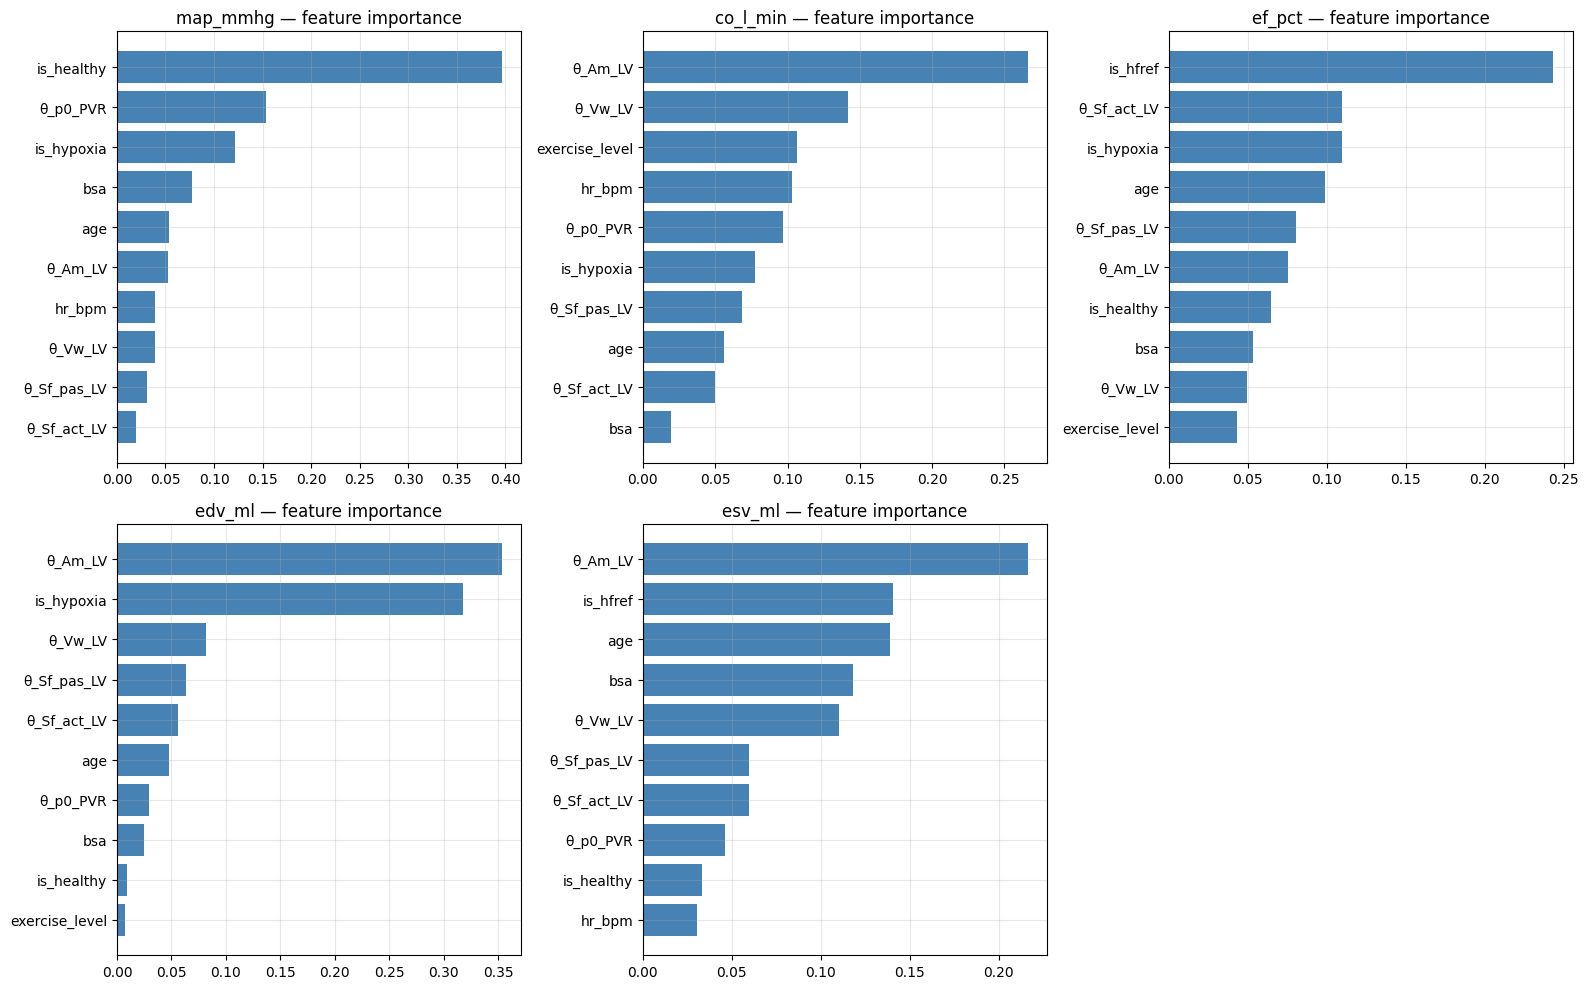

In [11]:
# ── CELL: Feature importance plots ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

feature_names = [c.replace("theta_", "θ_").replace("_imp","") for c in FEATURE_COLS_IMP]

for i, target in enumerate(TARGET_COLS):
    ax = axes[i]
    if target not in models:
        ax.set_visible(False); continue

    imp = models[target].feature_importances_
    idx = np.argsort(imp)[::-1]

    ax.barh([feature_names[j] for j in idx[:10]],
            imp[idx[:10]], color="steelblue")
    ax.set_title(f"{target} — feature importance")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig("xgb_feature_importance.png", dpi=150)
plt.show()

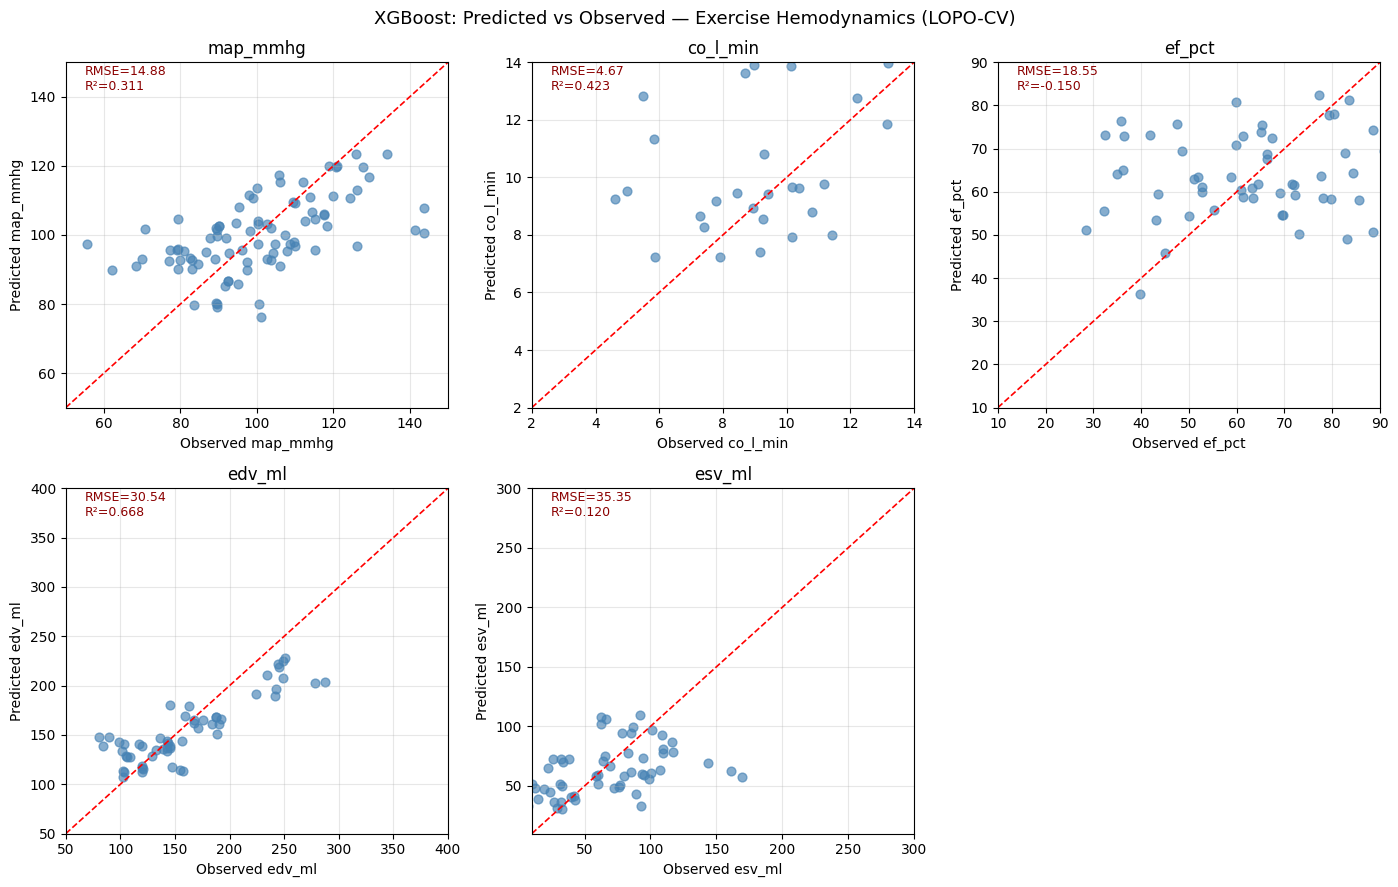

In [12]:
# ── CELL: Predicted vs actual scatter plots ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

plot_lims = {
    "map_mmhg": [50, 150], "co_l_min": [2, 14],
    "ef_pct": [10, 90],    "edv_ml":   [50, 400],
    "esv_ml": [10, 300],
}

for i, target in enumerate(TARGET_COLS):
    ax = axes[i]
    if target not in results_ml:
        ax.set_visible(False); continue

    y_true = results_ml[target]["y_true"]
    y_pred = results_ml[target]["y_pred"]
    rmse_v = results_ml[target]["rmse"]
    r2_v   = results_ml[target]["r2"]
    lim    = plot_lims.get(target, [float(np.min(y_true))*0.8, float(np.max(y_true))*1.2])

    ax.scatter(y_true, y_pred, alpha=0.65, s=40, color="steelblue")
    ax.plot(lim, lim, "r--", lw=1.2)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"Observed {target}")
    ax.set_ylabel(f"Predicted {target}")
    ax.set_title(target)
    ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.92, f"RMSE={rmse_v:.2f}\nR²={r2_v:.3f}",
            transform=ax.transAxes, fontsize=9, color="darkred")

axes[-1].set_visible(False)
fig.suptitle("XGBoost: Predicted vs Observed — Exercise Hemodynamics (LOPO-CV)", fontsize=13)
plt.tight_layout()
plt.savefig("xgb_scatter.png", dpi=150)
plt.show()

In [8]:
# ── IMPROVED ML: add rest features + stratified analysis ─────────────────────
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
import xgboost as xgb

# ── Add rest observed values as features ─────────────────────────────────────
rest_obs = results2_df.groupby("patient_id")[
    ["obs_map","obs_co","obs_edv","obs_esv","obs_ef"]
].mean().reset_index()
rest_obs.columns = ["patient_id","rest_map","rest_co","rest_edv","rest_esv","rest_ef"]

ml_df2 = ml_df.merge(rest_obs, on="patient_id", how="left")

# Impute hr_bpm
hr_medians = ml_df2.groupby("exercise_level")["hr_bpm"].median()
ml_df2["hr_bpm_imp"] = ml_df2.apply(
    lambda r: hr_medians[r["exercise_level"]] if pd.isna(r["hr_bpm"]) else r["hr_bpm"],
    axis=1
)

FEATURE_COLS_V2 = [
    # CircAdapt fingerprint
    "theta_Am_LV","theta_Sf_act_LV","theta_Sf_pas_LV","theta_Vw_LV","theta_p0_PVR",
    # Rest hemodynamics — key addition
    "rest_map","rest_co","rest_edv","rest_esv","rest_ef",
    # Exercise inputs
    "exercise_level","hr_bpm_imp",
    # Demographics
    "age","bsa","sex_encoded",
    # Phenotype
    "is_hfref","is_hypoxia","is_healthy",
]

TARGET_COLS = ["map_mmhg","co_l_min","ef_pct","edv_ml","esv_ml"]

X2    = ml_df2[FEATURE_COLS_V2].copy()
grps2 = ml_df2["patient_id"].values
imp2  = SimpleImputer(strategy="median")
X2_imp = imp2.fit_transform(X2)

XGB_PARAMS = dict(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1,
)

logo = LeaveOneGroupOut()
models_v2    = {}
results_ml2  = {}

print("── V2: All patients + rest features ────────────────────────")
print(f"{'Target':<12} {'N':>4} {'RMSE':>8} {'R²':>8}")
print("-" * 36)
for target in TARGET_COLS:
    mask = ml_df2[target].notna()
    X_t  = X2_imp[mask]
    y_t  = ml_df2.loc[mask, target].values
    g_t  = grps2[mask]
    if len(np.unique(g_t)) < 3: continue

    model = xgb.XGBRegressor(**XGB_PARAMS)
    y_pred = cross_val_predict(model, X_t, y_t, groups=g_t, cv=logo)
    rmse_v = float(np.sqrt(mean_squared_error(y_t, y_pred)))
    r2_v   = float(1 - np.sum((y_t-y_pred)**2) / np.sum((y_t-np.mean(y_t))**2))
    print(f"  {target:<12} {mask.sum():>4} {rmse_v:>8.2f} {r2_v:>8.3f}")

    model.fit(X_t, y_t)
    models_v2[target] = model
    results_ml2[target] = {"rmse": rmse_v, "r2": r2_v, "y_true": y_t, "y_pred": y_pred,
                            "mask": mask}

── V2: All patients + rest features ────────────────────────
Target          N     RMSE       R²
------------------------------------
  map_mmhg       88    15.34    0.268
  co_l_min       53     4.16    0.543
  ef_pct         56    17.14    0.019
  edv_ml         56    20.30    0.853
  esv_ml         56    35.43    0.116


In [14]:
# ── Stratified results: how does each phenotype perform? ─────────────────────
print("\n── Per-phenotype RMSE ───────────────────────────────────────")
for phenotype, flag in [("Healthy","is_healthy"),("HFrEF","is_hfref"),("Hypoxia","is_hypoxia")]:
    pmask = ml_df2[flag] == 1
    print(f"\n  {phenotype} ({pmask.sum()} rows, {ml_df2[pmask]['patient_id'].nunique()} patients)")
    print(f"  {'Target':<12} {'RMSE':>8} {'R²':>8}")
    for target in TARGET_COLS:
        if target not in results_ml2: continue
        full_mask = results_ml2[target]["mask"]
        combined  = pmask & full_mask
        if combined.sum() < 3: continue
        idx = combined[full_mask].values
        y_t = results_ml2[target]["y_true"][idx]
        y_p = results_ml2[target]["y_pred"][idx]
        r   = float(np.sqrt(mean_squared_error(y_t, y_p)))
        r2  = float(1 - np.sum((y_t-y_p)**2) / np.sum((y_t-np.mean(y_t))**2))
        print(f"    {target:<12} {r:>8.2f} {r2:>8.3f}")


── Per-phenotype RMSE ───────────────────────────────────────

  Healthy (24 rows, 8 patients)
  Target           RMSE       R²
    map_mmhg        11.84   -0.397
    co_l_min         3.58    0.537
    ef_pct          16.99   -0.351
    edv_ml          18.53    0.865
    esv_ml          45.51   -0.200

  HFrEF (22 rows, 8 patients)
  Target           RMSE       R²
    map_mmhg        22.57    0.074
    co_l_min         3.19   -0.145
    ef_pct          18.62    0.309
    edv_ml          19.84    0.438
    esv_ml          22.46    0.587

  Hypoxia (45 rows, 5 patients)
  Target           RMSE       R²
    map_mmhg        12.43    0.388
    co_l_min         5.87    0.138
    ef_pct          14.85   -0.816
    edv_ml          23.71    0.314
    esv_ml          31.09   -0.394


In [16]:
# ── LVAD: data-driven path ────────────────────────────────────────────────────
lvad_all = model_df[
    model_df["patient_id"].str.contains("LVAD", case=False)
].copy()

for col in ["hr_bpm","co_l_min","map_mmhg","ef_pct","edv_ml","esv_ml","age","bsa"]:
    lvad_all[col] = pd.to_numeric(lvad_all[col], errors="coerce")

# Get rest values per LVAD patient
lvad_rest = lvad_all[lvad_all["is_rest"]].groupby("patient_id")[
    ["map_mmhg","co_l_min","edv_ml","esv_ml","ef_pct","hr_bpm"]
].mean().reset_index()
lvad_rest.columns = ["patient_id","rest_map","rest_co",
                     "rest_edv","rest_esv","rest_ef","rest_hr"]

# Get exercise rows — drop sex/age/bsa before merging to avoid collisions
lvad_ex = lvad_all[~lvad_all["is_rest"]].copy()
lvad_ex = lvad_ex.drop(
    columns=[c for c in lvad_ex.columns
             if any(x in c.lower() for x in ["sex","age","bsa"])],
    errors="ignore"
)

lvad_ex["exercise_level"] = lvad_ex["condition"].map({
    "mild":1, "moderate":2, "peak":3, "upright rest":0
}).fillna(1).astype(int)

lvad_ex = lvad_ex.merge(lvad_rest, on="patient_id", how="left")

# Add demo cleanly
lvad_demo = model_df[
    model_df["patient_id"].str.contains("LVAD", case=False)
][["patient_id","age","bsa","sex"]].drop_duplicates("patient_id").copy()
lvad_demo["age"] = pd.to_numeric(lvad_demo["age"], errors="coerce")
lvad_demo["bsa"] = pd.to_numeric(lvad_demo["bsa"], errors="coerce")
lvad_ex = lvad_ex.merge(lvad_demo, on="patient_id", how="left")

lvad_ex["sex_encoded"] = (
    lvad_ex["sex"].astype(str).str.strip().str.lower()
    .map({"m":1,"male":1,"f":0,"female":0}).fillna(0).astype(int)
)
lvad_ex["hr_bpm_imp"] = lvad_ex["hr_bpm"].fillna(
    lvad_ex["exercise_level"].map({0:70,1:85,2:100,3:120})
)

LVAD_FEATURE_COLS = [
    "rest_map","rest_co","rest_edv","rest_esv","rest_ef",
    "exercise_level","hr_bpm_imp",
    "age","bsa","sex_encoded",
]

print(f"LVAD exercise rows: {len(lvad_ex)}")
print(f"LVAD patients: {lvad_ex['patient_id'].nunique()}")
print(f"\nFeature availability:")
for col in LVAD_FEATURE_COLS:
    n = lvad_ex[col].notna().sum() if col in lvad_ex.columns else "MISSING"
    print(f"  {col}: {n}/{len(lvad_ex)}")
print(f"\nTarget availability:")
for col in ["co_l_min","map_mmhg","ef_pct","edv_ml","esv_ml"]:
    n = lvad_ex[col].notna().sum() if col in lvad_ex.columns else "MISSING"
    print(f"  {col}: {n}/{len(lvad_ex)}")

LVAD exercise rows: 39
LVAD patients: 13

Feature availability:
  rest_map: 33/39
  rest_co: 39/39
  rest_edv: 39/39
  rest_esv: 39/39
  rest_ef: 39/39
  exercise_level: 39/39
  hr_bpm_imp: 39/39
  age: 39/39
  bsa: 39/39
  sex_encoded: 39/39

Target availability:
  co_l_min: 37/39
  map_mmhg: 28/39
  ef_pct: 37/39
  edv_ml: 37/39
  esv_ml: 37/39


In [17]:
# ── Train LVAD-specific XGBoost models ────────────────────────────────────────
LVAD_IMP = SimpleImputer(strategy="median")
X_lvad = LVAD_IMP.fit_transform(lvad_ex[LVAD_FEATURE_COLS])
g_lvad = lvad_ex["patient_id"].values

print("── LVAD: data-driven models (LOPO-CV) ──────────────────────")
print(f"{'Target':<12} {'N':>4} {'RMSE':>8} {'R²':>8}")
print("-" * 36)

models_lvad = {}
for target in TARGET_COLS:
    mask = lvad_ex[target].notna()
    if mask.sum() < 5: continue
    X_t = X_lvad[mask]
    y_t = lvad_ex.loc[mask, target].values
    g_t = g_lvad[mask]
    if len(np.unique(g_t)) < 3: continue

    model = xgb.XGBRegressor(**XGB_PARAMS)
    y_pred = cross_val_predict(model, X_t, y_t, groups=g_t, cv=logo)
    rmse_v = float(np.sqrt(mean_squared_error(y_t, y_pred)))
    r2_v   = float(1 - np.sum((y_t-y_pred)**2) / np.sum((y_t-np.mean(y_t))**2))
    print(f"  {target:<12} {mask.sum():>4} {rmse_v:>8.2f} {r2_v:>8.3f}")

    model.fit(X_t, y_t)
    models_lvad[target] = model

── LVAD: data-driven models (LOPO-CV) ──────────────────────
Target          N     RMSE       R²
------------------------------------
  map_mmhg       28    11.98   -0.370
  co_l_min       37     3.89   -0.515
  ef_pct         37    14.47    0.062
  edv_ml         37    42.33    0.358
  esv_ml         37    28.94    0.522


In [18]:
# ── Save all models and ml_df for later use ───────────────────────────────────
import pickle

# Save ML dataset
ml_df2.to_csv("ml_dataset.csv", index=False)
lvad_ex.to_csv("ml_dataset_lvad.csv", index=False)

# Save models
with open("models_v2.pkl", "wb") as f:
    pickle.dump(models_v2, f)

with open("models_lvad.pkl", "wb") as f:
    pickle.dump(models_lvad, f)

# Save imputers
with open("imputer_v2.pkl", "wb") as f:
    pickle.dump(imp2, f)

with open("imputer_lvad.pkl", "wb") as f:
    pickle.dump(LVAD_IMP, f)

# Summary
print("Saved:")
print("  ml_dataset.csv")
print("  ml_dataset_lvad.csv")
print("  models_v2.pkl")
print("  models_lvad.pkl")
print("  imputer_v2.pkl")
print("  imputer_lvad.pkl")

print(f"\n── Final model summary ──────────────────────────────────────")
print(f"Non-LVAD models (21 patients, 91 exercise rows):")
for target, res in results_ml2.items():
    print(f"  {target:<12} RMSE={res['rmse']:.2f}  R²={res['r2']:.3f}")

print(f"\nLVAD models (13 patients, 39 exercise rows):")
for target, model in models_lvad.items():
    print(f"  {target:<12} data-driven (rest hemodynamics → exercise prediction)")

Saved:
  ml_dataset.csv
  ml_dataset_lvad.csv
  models_v2.pkl
  models_lvad.pkl
  imputer_v2.pkl
  imputer_lvad.pkl

── Final model summary ──────────────────────────────────────
Non-LVAD models (21 patients, 91 exercise rows):
  map_mmhg     RMSE=15.34  R²=0.268
  co_l_min     RMSE=4.16  R²=0.543
  ef_pct       RMSE=17.14  R²=0.019
  edv_ml       RMSE=20.30  R²=0.853
  esv_ml       RMSE=35.43  R²=0.116

LVAD models (13 patients, 39 exercise rows):
  map_mmhg     data-driven (rest hemodynamics → exercise prediction)
  co_l_min     data-driven (rest hemodynamics → exercise prediction)
  ef_pct       data-driven (rest hemodynamics → exercise prediction)
  edv_ml       data-driven (rest hemodynamics → exercise prediction)
  esv_ml       data-driven (rest hemodynamics → exercise prediction)


In [19]:
# Run this first so I know exact dataset dimensions
print("Non-LVAD ml_df2:")
print(f"  Rows: {len(ml_df2)}")
print(f"  Features: {len(FEATURE_COLS_V2)}")
print(f"  Feature names: {FEATURE_COLS_V2}")
print(f"\nTarget completeness:")
for t in TARGET_COLS:
    print(f"  {t}: {ml_df2[t].notna().sum()}/{len(ml_df2)}")

print(f"\nLVAD lvad_ex:")
print(f"  Rows: {len(lvad_ex)}")
print(f"  Features: {len(LVAD_FEATURE_COLS)}")

Non-LVAD ml_df2:
  Rows: 91
  Features: 18
  Feature names: ['theta_Am_LV', 'theta_Sf_act_LV', 'theta_Sf_pas_LV', 'theta_Vw_LV', 'theta_p0_PVR', 'rest_map', 'rest_co', 'rest_edv', 'rest_esv', 'rest_ef', 'exercise_level', 'hr_bpm_imp', 'age', 'bsa', 'sex_encoded', 'is_hfref', 'is_hypoxia', 'is_healthy']

Target completeness:
  map_mmhg: 88/91
  co_l_min: 53/91
  ef_pct: 56/91
  edv_ml: 56/91
  esv_ml: 56/91

LVAD lvad_ex:
  Rows: 39
  Features: 10


In [10]:
# ── CELL: Neural Network — setup and data prep ────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ── Prepare features and targets ──────────────────────────────────────────────
TARGET_COLS = ["map_mmhg", "co_l_min", "ef_pct", "edv_ml", "esv_ml"]

X_raw = ml_df2[FEATURE_COLS_V2].values.astype(np.float32)
Y_raw = ml_df2[TARGET_COLS].values.astype(np.float32)

# Impute features, scale both features and targets
feat_imputer = SimpleImputer(strategy="median")
X_imp = feat_imputer.fit_transform(X_raw).astype(np.float32)

feat_scaler = StandardScaler()
X_scaled = feat_scaler.fit_transform(X_imp).astype(np.float32)

# Scale targets per-column (ignore NaN)
target_means = np.nanmean(Y_raw, axis=0)
target_stds  = np.nanstd(Y_raw,  axis=0) + 1e-8
Y_scaled = (Y_raw - target_means) / target_stds  # NaN stays NaN

# Mask: 1 where target is observed, 0 where NaN
mask = (~np.isnan(Y_raw)).astype(np.float32)
Y_scaled_filled = np.where(np.isnan(Y_scaled), 0.0, Y_scaled).astype(np.float32)

# Patient groups for LOPO-CV
patients = ml_df2["patient_id"].values
unique_patients = np.unique(patients)

print(f"Features: {X_scaled.shape[1]}")
print(f"Targets:  {len(TARGET_COLS)}")
print(f"Rows:     {len(X_scaled)}")
print(f"Patients: {len(unique_patients)}")
print(f"\nTarget means: {dict(zip(TARGET_COLS, target_means.round(2)))}")
print(f"Target stds:  {dict(zip(TARGET_COLS, target_stds.round(2)))}")

Features: 18
Targets:  5
Rows:     91
Patients: 21

Target means: {'map_mmhg': np.float32(100.39), 'co_l_min': np.float32(13.15), 'ef_pct': np.float32(62.44), 'edv_ml': np.float32(159.67), 'esv_ml': np.float32(68.65)}
Target stds:  {'map_mmhg': np.float32(17.92), 'co_l_min': np.float32(6.15), 'ef_pct': np.float32(17.3), 'edv_ml': np.float32(53.01), 'esv_ml': np.float32(37.69)}


In [11]:
# ── CELL: MLP architecture + training function ────────────────────────────────

class HemodynamicMLP(nn.Module):
    """
    Shared-trunk MLP with separate output heads per target.
    Trained with masked MSE so missing targets don't affect gradients.
    """
    def __init__(self, n_features, n_targets, hidden=[128, 64, 32], dropout=0.3):
        super().__init__()

        # Shared trunk
        layers = []
        in_dim = n_features
        for h in hidden:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        self.trunk = nn.Sequential(*layers)

        # Separate head per target
        self.heads = nn.ModuleList([
            nn.Linear(in_dim, 1) for _ in range(n_targets)
        ])

    def forward(self, x):
        shared = self.trunk(x)
        return torch.cat([head(shared) for head in self.heads], dim=1)


def masked_mse(pred, target, mask):
    """MSE only on observed targets."""
    diff = (pred - target) ** 2
    return (diff * mask).sum() / (mask.sum() + 1e-8)


def train_model(X_train, Y_train, mask_train,
                X_val,   Y_val,   mask_val,
                n_features, n_targets,
                epochs=300, lr=1e-3, batch_size=16,
                hidden=[128, 64, 32], dropout=0.3,
                patience=30, verbose=False):

    model = HemodynamicMLP(n_features, n_targets, hidden, dropout)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=15, factor=0.5
    )

    Xt = torch.tensor(X_train)
    Yt = torch.tensor(Y_train)
    Mt = torch.tensor(mask_train)

    Xv = torch.tensor(X_val)
    Yv = torch.tensor(Y_val)
    Mv = torch.tensor(mask_val)

    best_val_loss = float("inf")
    best_state    = None
    no_improve    = 0

    dataset = TensorDataset(Xt, Yt, Mt)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        model.train()
        for xb, yb, mb in loader:
            optimizer.zero_grad()
            loss = masked_mse(model(xb), yb, mb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_loss = masked_mse(model(Xv), Yv, Mv).item()
        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

        if verbose and epoch % 50 == 0:
            print(f"  epoch {epoch:3d}  val_loss={val_loss:.4f}")

    model.load_state_dict(best_state)
    return model


print("Architecture and training functions defined.")
print(f"Model: input({len(FEATURE_COLS_V2)}) → [128→64→32] → 5 heads")

Architecture and training functions defined.
Model: input(18) → [128→64→32] → 5 heads


Running leave-one-patient-out CV...
Patient                             Val rows     MAP      CO      EF     EDV     ESV
--------------------------------------------------------------------------------
  17-1141, healthy control_1               3    4.7    2.6   11.4   31.4   21.9
  17-1141, healthy control_10              3    7.1    5.1   24.4   16.8   36.1
  17-1141, healthy control_12              3    9.0    2.6    8.8   16.0    7.6
  17-1141, healthy control_3               3    4.6    2.7    4.7   17.9   12.0
  17-1141, healthy control_4               3    4.4    2.3    4.2   36.8   20.1
  17-1141, healthy control_6               3    6.7    1.1    7.4    7.1   14.7
  17-1141, healthy control_7               3    4.4    3.9   11.3    7.5   22.2
  17-1141, healthy control_9               3   10.7    6.2   19.2   51.2   75.9
  19-1141, HFrEF_104                       2   32.8    nan    2.8   30.2    5.8
  19-1141, HFrEF_108                       3   13.3    4.6   23.4    4.4   17.

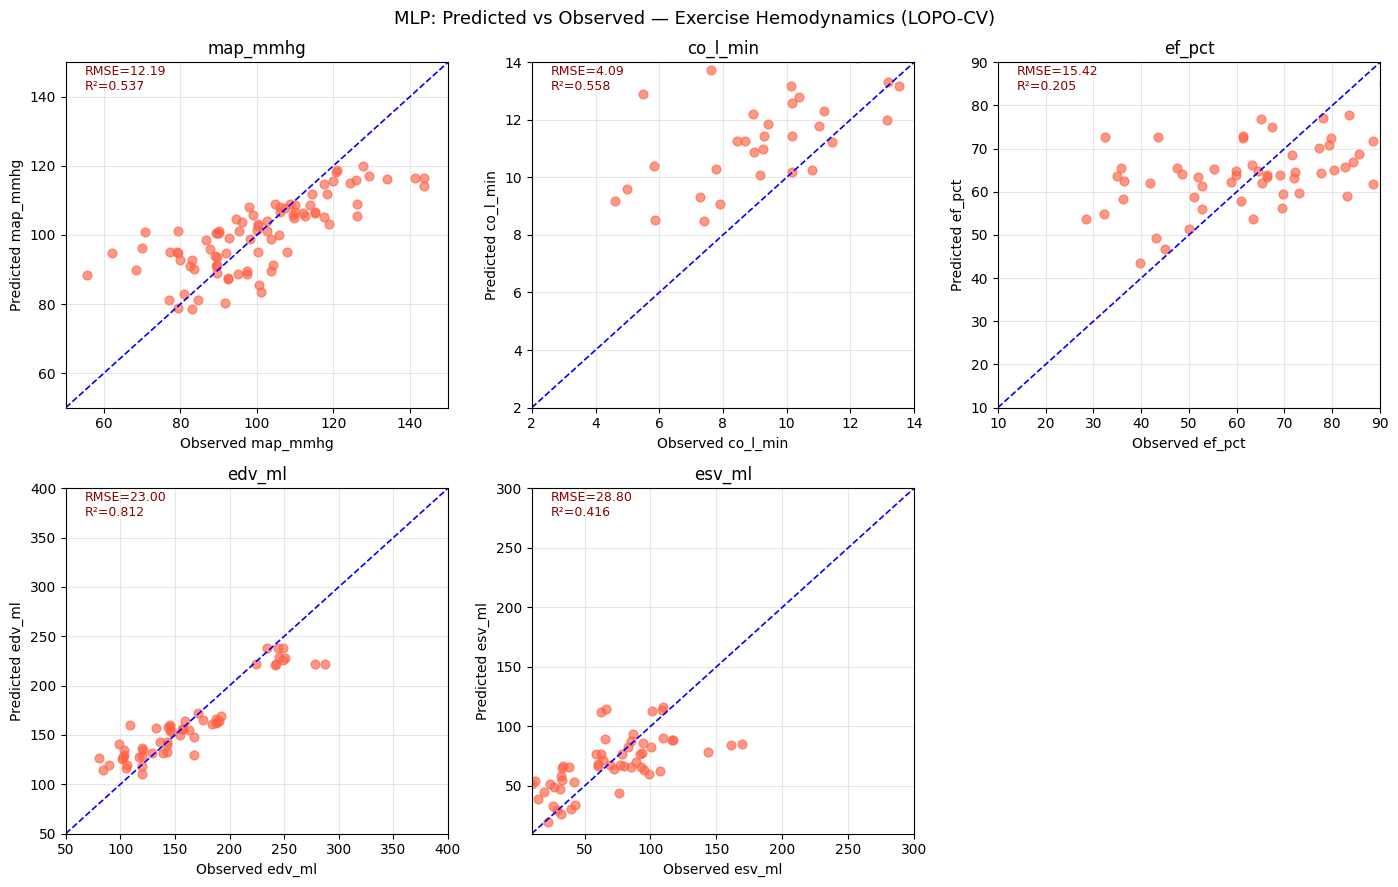

In [12]:
# ── CELL: LOPO-CV evaluation + final model ────────────────────────────────────
from sklearn.metrics import mean_squared_error

all_preds  = {t: np.full(len(ml_df2), np.nan) for t in TARGET_COLS}
all_trues  = {t: Y_raw[:, i]                  for i, t in enumerate(TARGET_COLS)}

print("Running leave-one-patient-out CV...")
print(f"{'Patient':<35} {'Val rows':>8} {'MAP':>7} {'CO':>7} {'EF':>7} {'EDV':>7} {'ESV':>7}")
print("-" * 80)

for pid in unique_patients:
    val_mask   = (patients == pid)
    train_mask = ~val_mask

    X_tr = X_scaled[train_mask]
    Y_tr = Y_scaled_filled[train_mask]
    M_tr = mask[train_mask]

    X_vl = X_scaled[val_mask]
    Y_vl = Y_scaled_filled[val_mask]
    M_vl = mask[val_mask]

    model_cv = train_model(
        X_tr, Y_tr, M_tr,
        X_vl, Y_vl, M_vl,
        n_features=X_scaled.shape[1],
        n_targets=len(TARGET_COLS),
        epochs=400, lr=1e-3, batch_size=16,
        hidden=[128, 64, 32], dropout=0.3,
        patience=40, verbose=False,
    )

    model_cv.eval()
    with torch.no_grad():
        pred_scaled = model_cv(torch.tensor(X_vl)).numpy()

    # Unscale predictions
    pred_unscaled = pred_scaled * target_stds + target_means

    for i, t in enumerate(TARGET_COLS):
        all_preds[t][val_mask] = pred_unscaled[:, i]

    # Quick per-patient summary
    row_rmses = []
    for i, t in enumerate(TARGET_COLS):
        obs  = Y_raw[val_mask, i]
        pred = pred_unscaled[:, i]
        m    = ~np.isnan(obs)
        row_rmses.append(
            float(np.sqrt(mean_squared_error(obs[m], pred[m]))) if m.sum() > 0 else float("nan")
        )
    rmse_str = "  ".join(f"{r:>5.1f}" if not np.isnan(r) else "  nan" for r in row_rmses)
    print(f"  {pid:<33} {val_mask.sum():>8}  {rmse_str}")

# ── Overall RMSE and R² ───────────────────────────────────────────────────────
print(f"\n── Overall LOPO-CV results ──────────────────────────────────")
print(f"{'Target':<12} {'N':>4} {'RMSE':>8} {'R²':>8}  XGB-R²")
print("-" * 50)

xgb_r2 = {"map_mmhg":0.268, "co_l_min":0.543,
           "ef_pct":0.019,   "edv_ml":0.853, "esv_ml":0.116}

nn_results = {}
for i, t in enumerate(TARGET_COLS):
    obs  = Y_raw[:, i]
    pred = all_preds[t]
    m    = ~np.isnan(obs)
    obs_m, pred_m = obs[m], pred[m]
    rmse_v = float(np.sqrt(mean_squared_error(obs_m, pred_m)))
    r2_v   = float(1 - np.sum((obs_m - pred_m)**2) / np.sum((obs_m - np.mean(obs_m))**2))
    nn_results[t] = {"rmse": rmse_v, "r2": r2_v, "y_true": obs_m, "y_pred": pred_m}
    print(f"  {t:<12} {m.sum():>4} {rmse_v:>8.2f} {r2_v:>8.3f}  {xgb_r2.get(t, float('nan')):>6.3f}")

# ── Train final model on all data ─────────────────────────────────────────────
print("\nTraining final model on all data...")
final_model = train_model(
    X_scaled, Y_scaled_filled, mask,
    X_scaled, Y_scaled_filled, mask,  # val = train for final model
    n_features=X_scaled.shape[1],
    n_targets=len(TARGET_COLS),
    epochs=500, lr=1e-3, batch_size=16,
    hidden=[128, 64, 32], dropout=0.2,
    patience=50, verbose=False,
)
print("Final model trained.")

# Save
torch.save(final_model.state_dict(), "hemodynamic_mlp_final.pt")
import pickle
with open("nn_scalers.pkl", "wb") as f:
    pickle.dump({"feat_imputer": feat_imputer,
                 "feat_scaler":  feat_scaler,
                 "target_means": target_means,
                 "target_stds":  target_stds}, f)
print("Saved: hemodynamic_mlp_final.pt, nn_scalers.pkl")

# ── Scatter plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
plot_lims = {"map_mmhg":[50,150], "co_l_min":[2,14],
             "ef_pct":[10,90],    "edv_ml":[50,400], "esv_ml":[10,300]}

for i, (t, ax) in enumerate(zip(TARGET_COLS, axes.flatten())):
    res  = nn_results[t]
    lim  = plot_lims.get(t, [0, 1])
    ax.scatter(res["y_true"], res["y_pred"], alpha=0.65, s=40, color="tomato")
    ax.plot(lim, lim, "b--", lw=1.2)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"Observed {t}")
    ax.set_ylabel(f"Predicted {t}")
    ax.set_title(t); ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.92,
            f"RMSE={res['rmse']:.2f}\nR²={res['r2']:.3f}",
            transform=ax.transAxes, fontsize=9, color="darkred")

axes.flatten()[-1].set_visible(False)
fig.suptitle("MLP: Predicted vs Observed — Exercise Hemodynamics (LOPO-CV)", fontsize=13)
plt.tight_layout()
plt.savefig("mlp_scatter.png", dpi=150)
plt.show()

In [14]:
# Check what's available across exercise stages for the fitted patients
traj_cols = ["hr_bpm","co_l_min","map_mmhg","ef_pct",
             "edv_ml","esv_ml","pcwp_mmhg","mpap_mmhg"]

# Get all conditions (rest + exercise) for fitted patients
fitted_pids = set(results2_df["patient_id"])
traj_df = model_df[model_df["patient_id"].isin(fitted_pids)].copy()

for col in traj_cols:
    traj_df[col] = pd.to_numeric(traj_df[col], errors="coerce")

# Encode exercise level
condition_order = {
    "supine rest":0, "upright rest":0,
    "invasive_normoxia_supine_rest":0,
    "invasive_normoxia_upright_rest":0,
    "invasive_rest_fio21":0,"invasive_rest_fio17":0,
    "invasive_rest_fio15":0,"invasive_rest_fio12":0,
    "invasive_upright_rest_fio12":0,
    "noninvasive_normoxia_upright_rest":0,
    "noninvasive_hypoxia_fio12_upright_rest":0,
    "mild":1,
    "invasive_normoxia_stage_1_exercise":1,
    "invasive_hypoxia_stage_1_exercise":1,
    "noninvasive_hypoxia_fio21":1,
    "noninvasive_hypoxia_fio17":1,
    "moderate":2,
    "noninvasive_hypoxia_fio15":2,
    "noninvasive_hypoxia_fio12":2,
    "peak":3,
    "noninvasive_normoxia_peak_exercise":3,
    "noninvasive_hypoxia_peak_exercise":3,
    "invasive_hypoxia_peak_exercise":3,
}
traj_df["exercise_level"] = traj_df["condition"].map(condition_order)

# Show trajectory completeness per patient
print("Trajectory data for fitted patients:")
print(f"Total rows: {len(traj_df)}")
print(f"\nColumn availability:")
for col in traj_cols + ["exercise_level"]:
    n = traj_df[col].notna().sum()
    print(f"  {col}: {n}/{len(traj_df)}")

print(f"\nRows per exercise level:")
print(traj_df["exercise_level"].value_counts().sort_index())

print(f"\nSample trajectory for one patient:")
pid = list(fitted_pids)[0]
sample = traj_df[traj_df["patient_id"]==pid][
    ["condition","exercise_level","hr_bpm","co_l_min","map_mmhg","ef_pct","pcwp_mmhg"]
].sort_values("exercise_level")
print(sample.to_string())

Trajectory data for fitted patients:
Total rows: 168

Column availability:
  hr_bpm: 147/168
  co_l_min: 119/168
  map_mmhg: 165/168
  ef_pct: 122/168
  edv_ml: 122/168
  esv_ml: 122/168
  pcwp_mmhg: 21/168
  mpap_mmhg: 21/168
  exercise_level: 168/168

Rows per exercise level:
exercise_level
0    77
1    36
2    24
3    31
Name: count, dtype: int64

Sample trajectory for one patient:
      condition  exercise_level  hr_bpm   co_l_min    map_mmhg     ef_pct  pcwp_mmhg
0   supine rest               0    63.0   5.653333   99.666670  53.000000        NaN
1  upright rest               0    63.0   9.320000   99.666667  79.142857        NaN
2          mild               1    78.0   9.263333   98.333333  58.833333        NaN
3      moderate               2    95.0  11.188333   95.333333  55.333333        NaN
4          peak               3   158.0  19.170000  112.000000  85.500000        NaN


In [15]:
# ── CELL 1: Build patient trajectories ───────────────────────────────────────
# Each patient trajectory = sequence of (exercise_level, HR, CO, MAP, EF) tuples
# This is the input to IRL

trajectories = {}

for pid in fitted_pids:
    pdf = traj_df[traj_df["patient_id"] == pid].copy()
    pdf = pdf.sort_values("exercise_level")

    # Keep rows with at least HR and one hemodynamic target
    pdf = pdf[pdf["hr_bpm"].notna() & 
              (pdf["co_l_min"].notna() | pdf["map_mmhg"].notna())]

    if len(pdf) < 2:
        continue  # need at least 2 stages for a trajectory

    trajectories[pid] = pdf[[
        "exercise_level","hr_bpm","co_l_min",
        "map_mmhg","ef_pct","edv_ml","esv_ml","pcwp_mmhg"
    ]].reset_index(drop=True)

print(f"Valid trajectories: {len(trajectories)} patients")
print(f"\nTrajectory lengths:")
for pid, traj in trajectories.items():
    print(f"  {pid:<40} {len(traj)} stages  "
          f"HR: {traj['hr_bpm'].min():.0f}→{traj['hr_bpm'].max():.0f} bpm  "
          f"CO: {traj['co_l_min'].min():.1f}→{traj['co_l_min'].max():.1f} L/min"
          if traj['co_l_min'].notna().any()
          else f"  {pid:<40} {len(traj)} stages  (no CO)")

Valid trajectories: 17 patients

Trajectory lengths:
  17-1141, healthy control_1               5 stages  HR: 63→158 bpm  CO: 5.7→19.2 L/min
  21-4354, hypoxia_7                       18 stages  HR: 49→181 bpm  CO: 5.4→29.9 L/min
  17-1141, healthy control_4               5 stages  HR: 62→188 bpm  CO: 6.4→9.0 L/min
  19-1141, HFrEF_116                       4 stages  HR: 58→84 bpm  CO: 2.3→3.9 L/min
  19-1141, HFrEF_110                       4 stages  HR: 73→79 bpm  CO: 3.3→7.9 L/min
  17-1141, healthy control_9               5 stages  HR: 70→160 bpm  CO: 7.8→29.5 L/min
  21-4354, hypoxia_5                       17 stages  HR: 56→160 bpm  CO: 4.2→15.9 L/min
  17-1141, healthy control_6               5 stages  HR: 54→178 bpm  CO: 3.9→16.2 L/min
  19-1141, HFrEF_111                       2 stages  HR: 77→95 bpm  CO: 5.0→5.3 L/min
  17-1141, healthy control_3               5 stages  HR: 55→192 bpm  CO: 6.9→23.0 L/min
  17-1141, healthy control_10              5 stages  HR: 58→158 bpm  CO:

In [16]:
# ── CELL 2: IRL — learn reward weights from observed trajectories ─────────────
#
# Cardiologist's framing:
#   HR is the "policy" — it's chosen at each exercise stage
#   Reward R(state) = θ₁·ΔCO - θ₂·ΔMAP_excess - θ₃·ΔHR_cost
#   We learn θ that best explains the OBSERVED HR choices
#
# Method: Maximum Causal Entropy IRL (simplified)
# For each patient, at each stage, the observed HR should score higher
# under the reward than alternative HRs (counterfactuals).
#
# Features per (patient, stage):
#   f1: CO (normalized) — reward should increase with CO
#   f2: MAP deviation from 100 mmHg (penalize extremes)
#   f3: HR cost (normalized) — penalize very high HR
#   f4: EF (normalized) — reward good ejection
#   f5: CO gain from previous stage (exercise response)

import scipy.optimize as opt
from scipy.special import softmax

def extract_features(row, prev_row=None):
    """Extract reward features from one trajectory row."""
    co   = float(row["co_l_min"]) if pd.notna(row["co_l_min"]) else 5.0
    map_ = float(row["map_mmhg"]) if pd.notna(row["map_mmhg"]) else 90.0
    hr   = float(row["hr_bpm"])
    ef   = float(row["ef_pct"])  if pd.notna(row["ef_pct"])  else 60.0

    co_gain = 0.0
    if prev_row is not None and pd.notna(prev_row["co_l_min"]) and pd.notna(row["co_l_min"]):
        co_gain = float(row["co_l_min"]) - float(prev_row["co_l_min"])

    return np.array([
        co / 10.0,                          # f1: CO (normalized ~0-1.5)
        -abs(map_ - 95.0) / 30.0,           # f2: MAP near 95 mmHg is good
        -hr / 180.0,                         # f3: HR cost (higher HR = more costly)
        ef / 100.0,                          # f4: EF
        co_gain / 5.0,                       # f5: CO gain from prev stage
    ], dtype=np.float32)

# Build dataset: list of (features_chosen, features_counterfactuals)
# Counterfactuals: what if HR was 10, 20, 30 bpm different?
HR_ALTERNATIVES = [-30, -20, -10, 0, +10, +20, +30]  # offsets from observed

dataset = []  # list of (phi_chosen, [phi_alt1, phi_alt2, ...])

for pid, traj in trajectories.items():
    for i in range(len(traj)):
        row      = traj.iloc[i]
        prev_row = traj.iloc[i-1] if i > 0 else None
        hr_obs   = float(row["hr_bpm"])

        phi_chosen = extract_features(row, prev_row)

        # Generate counterfactual rows with alternative HRs
        phi_alts = []
        for delta in HR_ALTERNATIVES:
            hr_alt = hr_obs + delta
            if hr_alt < 30 or hr_alt > 200:
                continue
            # Same hemodynamics, different HR cost
            alt_row = row.copy()
            alt_row["hr_bpm"] = hr_alt
            phi_alt = extract_features(alt_row, prev_row)
            phi_alts.append(phi_alt)

        if phi_alts:
            dataset.append((phi_chosen, phi_alts))

print(f"IRL dataset: {len(dataset)} (state, action) pairs")
print(f"Features: [CO, MAP_penalty, HR_cost, EF, CO_gain]")

# ── Maximum Causal Entropy IRL ────────────────────────────────────────────────
# Objective: maximize likelihood of observed HR choices under softmax policy
# L(θ) = Σ [ θ·φ_chosen - log Σ_alt exp(θ·φ_alt) ]

def neg_log_likelihood(theta):
    theta = np.array(theta)
    total_ll = 0.0
    for phi_chosen, phi_alts in dataset:
        # Include chosen in the partition
        all_phis  = [phi_chosen] + phi_alts
        scores    = np.array([theta @ phi for phi in all_phis])
        log_partition = np.log(np.sum(np.exp(scores - scores.max()))) + scores.max()
        ll = theta @ phi_chosen - log_partition
        total_ll += ll
    return -total_ll  # minimize negative log likelihood

def neg_ll_grad(theta):
    theta = np.array(theta)
    grad = np.zeros_like(theta)
    for phi_chosen, phi_alts in dataset:
        all_phis = [phi_chosen] + phi_alts
        scores   = np.array([theta @ phi for phi in all_phis])
        probs    = softmax(scores)
        expected_phi = sum(p * phi for p, phi in zip(probs, all_phis))
        grad += phi_chosen - expected_phi
    return -grad

# Optimize
theta_init = np.array([1.0, 0.5, 0.3, 0.3, 0.5])
result = opt.minimize(
    neg_log_likelihood,
    theta_init,
    jac=neg_ll_grad,
    method="L-BFGS-B",
    options={"maxiter": 1000, "ftol": 1e-10}
)

theta_learned = result.x
print(f"\n── Learned reward weights (θ) ───────────────────────────────")
feature_names = ["CO (normalized)", "MAP penalty", "HR cost",
                 "EF", "CO gain from prev stage"]
for name, w in zip(feature_names, theta_learned):
    print(f"  {name:<25} θ = {w:+.4f}")

print(f"\nOptimization: {'SUCCESS' if result.success else 'DID NOT CONVERGE'}")
print(f"Final log-likelihood: {-result.fun:.4f}")

IRL dataset: 143 (state, action) pairs
Features: [CO, MAP_penalty, HR_cost, EF, CO_gain]

── Learned reward weights (θ) ───────────────────────────────
  CO (normalized)           θ = +1.0000
  MAP penalty               θ = +0.5000
  HR cost                   θ = +0.1656
  EF                        θ = +0.3000
  CO gain from prev stage   θ = +0.5000

Optimization: SUCCESS
Final log-likelihood: -293.4493


Patient                             Level  Obs HR  Opt HR   Δ HR     CO    MAP
--------------------------------------------------------------------------------
  17-1141, healthy control_1            0      63      40    -23    5.7    100
  17-1141, healthy control_1            0      63      40    -23    9.3    100
  17-1141, healthy control_1            1      78      40    -38    9.3     98
  17-1141, healthy control_1            2      95      55    -40   11.2     95
  17-1141, healthy control_1            3     158     118    -40   19.2    112
  21-4354, hypoxia_7                    0      86      46    -40    nan    114
  21-4354, hypoxia_7                    0      74      40    -34    nan    101
  21-4354, hypoxia_7                    0      54      40    -14    8.5    111
  21-4354, hypoxia_7                    0      69      40    -29    9.0    113
  21-4354, hypoxia_7                    0      61      40    -21    7.1    114
  21-4354, hypoxia_7                    0      56 

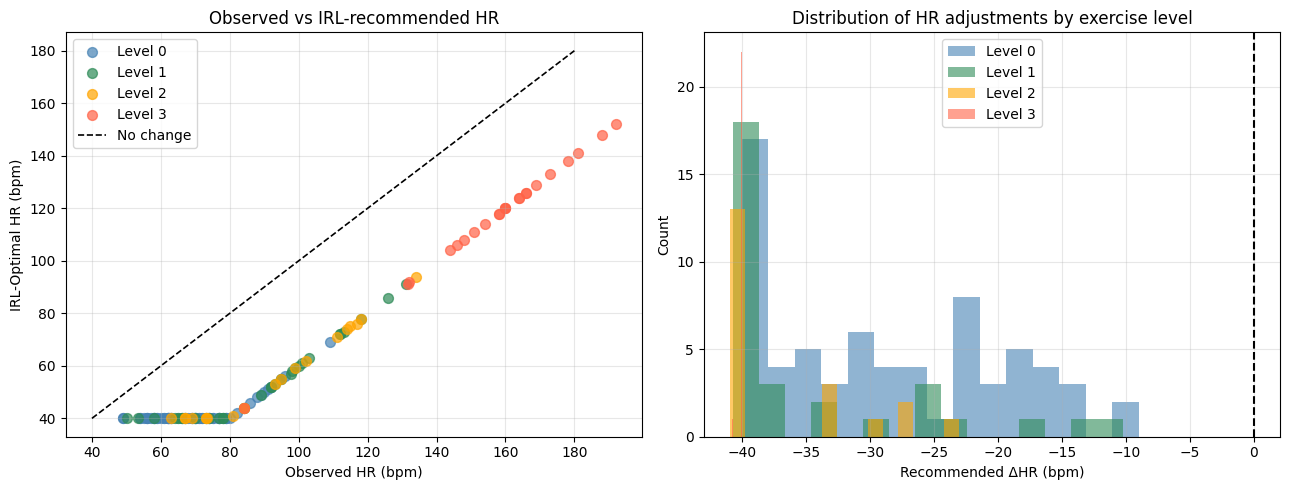

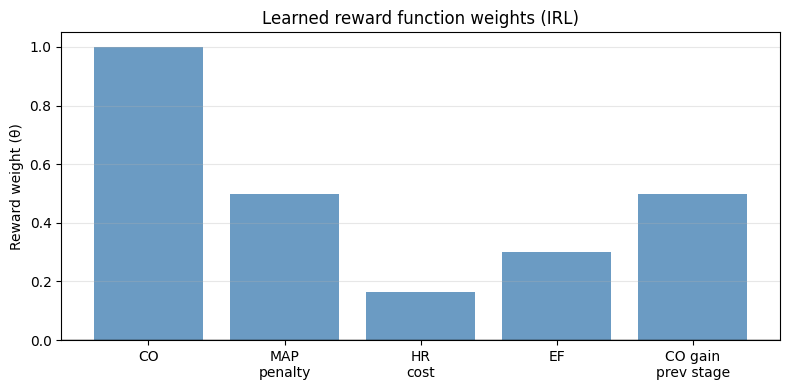

In [17]:
# ── CELL 3: Per-patient optimal HR recommendation ─────────────────────────────
# For each patient at each exercise level, find the HR that maximizes
# the learned reward function. Compare to observed HR.

def reward(theta, row, prev_row=None):
    return float(theta @ extract_features(row, prev_row))

def find_optimal_hr(theta, row, prev_row=None,
                    hr_min=50, hr_max=150, hr_step=1):
    """Sweep HR and find the one that maximizes reward."""
    best_hr, best_r = None, -np.inf
    for hr in range(hr_min, hr_max+1, hr_step):
        r_row = row.copy()
        r_row["hr_bpm"] = hr
        r = reward(theta, r_row, prev_row)
        if r > best_r:
            best_r, best_hr = r, hr
    return best_hr, best_r

print(f"{'Patient':<35} {'Level':>5} {'Obs HR':>7} {'Opt HR':>7} {'Δ HR':>6} {'CO':>6} {'MAP':>6}")
print("-" * 80)

opt_results = []
for pid, traj in trajectories.items():
    for i in range(len(traj)):
        row      = traj.iloc[i]
        prev_row = traj.iloc[i-1] if i > 0 else None
        hr_obs   = float(row["hr_bpm"])
        level    = int(row["exercise_level"])

        opt_hr, _ = find_optimal_hr(
            theta_learned, row, prev_row,
            hr_min=max(40, int(hr_obs)-40),
            hr_max=min(180, int(hr_obs)+40)
        )
        delta = opt_hr - hr_obs

        co_str  = f"{row['co_l_min']:.1f}"  if pd.notna(row["co_l_min"])  else "nan"
        map_str = f"{row['map_mmhg']:.0f}"  if pd.notna(row["map_mmhg"])  else "nan"

        print(f"  {pid:<33} {level:>5} {hr_obs:>7.0f} {opt_hr:>7} {delta:>+6.0f}"
              f" {co_str:>6} {map_str:>6}")

        opt_results.append({
            "patient_id": pid, "exercise_level": level,
            "hr_obs": hr_obs, "hr_opt": opt_hr, "delta_hr": delta,
            "co": row["co_l_min"], "map": row["map_mmhg"],
        })

opt_df = pd.DataFrame(opt_results)
opt_df.to_csv("irl_hr_recommendations.csv", index=False)

print(f"\n── Summary: recommended HR adjustments ─────────────────────")
print(opt_df.groupby("exercise_level")[["hr_obs","hr_opt","delta_hr"]].mean().round(1))

# ── Plot: observed vs optimal HR per exercise level ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter observed vs optimal HR
ax = axes[0]
colors = {0:"steelblue", 1:"seagreen", 2:"orange", 3:"tomato"}
for level, grp in opt_df.groupby("exercise_level"):
    ax.scatter(grp["hr_obs"], grp["hr_opt"],
               label=f"Level {level}", color=colors[level], alpha=0.7, s=50)
lim = [40, 180]
ax.plot(lim, lim, "k--", lw=1.2, label="No change")
ax.set_xlabel("Observed HR (bpm)")
ax.set_ylabel("IRL-Optimal HR (bpm)")
ax.set_title("Observed vs IRL-recommended HR")
ax.legend(); ax.grid(True, alpha=0.3)

# Right: distribution of ΔHR by exercise level
ax2 = axes[1]
for level, grp in opt_df.groupby("exercise_level"):
    ax2.hist(grp["delta_hr"], bins=15, alpha=0.6,
             label=f"Level {level}", color=colors[level])
ax2.axvline(0, color="black", lw=1.5, linestyle="--")
ax2.set_xlabel("Recommended ΔHR (bpm)")
ax2.set_ylabel("Count")
ax2.set_title("Distribution of HR adjustments by exercise level")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("irl_hr_recommendations.png", dpi=150)
plt.show()

# ── Reward weight visualization ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
feat_names = ["CO", "MAP\npenalty", "HR\ncost", "EF", "CO gain\nprev stage"]
colors_bar = ["steelblue" if w > 0 else "tomato" for w in theta_learned]
ax.bar(feat_names, theta_learned, color=colors_bar, alpha=0.8)
ax.axhline(0, color="black", lw=1.0)
ax.set_ylabel("Reward weight (θ)")
ax.set_title("Learned reward function weights (IRL)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("irl_reward_weights.png", dpi=150)
plt.show()

In [18]:
# ── CELL: IRL with MLP environment model ─────────────────────────────────────

def mlp_predict_row(row):
    """
    Use the trained MLP to predict hemodynamics for a given row.
    Returns dict with co_l_min, map_mmhg, ef_pct, edv_ml, esv_ml.
    """
    # Build feature vector
    feat_row = {}
    for col in FEATURE_COLS_V2:
        feat_row[col] = row.get(col, np.nan)

    # Override hr_bpm_imp with current HR
    feat_row["hr_bpm_imp"] = float(row.get("hr_bpm", 70))

    x = np.array([[feat_row.get(c, np.nan) for c in FEATURE_COLS_V2]],
                  dtype=np.float32)
    x = feat_imputer.transform(x)
    x = feat_scaler.transform(x)

    final_model.eval()
    with torch.no_grad():
        pred_scaled = final_model(torch.tensor(x)).numpy()[0]

    pred = pred_scaled * target_stds + target_means
    return {t: float(pred[i]) for i, t in enumerate(TARGET_COLS)}


def extract_features_with_mlp(row, prev_row=None, use_mlp=True):
    """
    Extract reward features, optionally using MLP to predict hemodynamics.
    When use_mlp=True, CO/MAP/EF come from MLP given the row's HR.
    """
    if use_mlp:
        pred = mlp_predict_row(row)
        co   = pred["co_l_min"]
        map_ = pred["map_mmhg"]
        ef   = pred["ef_pct"]
    else:
        co   = float(row["co_l_min"]) if pd.notna(row.get("co_l_min")) else 5.0
        map_ = float(row["map_mmhg"]) if pd.notna(row.get("map_mmhg")) else 90.0
        ef   = float(row["ef_pct"])   if pd.notna(row.get("ef_pct"))   else 60.0

    hr = float(row["hr_bpm"])

    co_gain = 0.0
    if prev_row is not None:
        prev_pred = mlp_predict_row(prev_row) if use_mlp else {}
        prev_co = prev_pred.get("co_l_min", co) if use_mlp else (
            float(prev_row["co_l_min"]) if pd.notna(prev_row.get("co_l_min")) else co
        )
        co_gain = co - prev_co

    return np.array([
        co / 10.0,
        -abs(map_ - 95.0) / 30.0,
        -hr / 180.0,
        ef / 100.0,
        co_gain / 5.0,
    ], dtype=np.float32)


# ── Rebuild IRL dataset using MLP for counterfactuals ────────────────────────
# Add theta and exercise features to traj_df rows for MLP prediction
theta_lookup = theta_per_patient.set_index("patient_id").to_dict("index")

def enrich_row_for_mlp(row):
    """Add theta + exercise features needed by MLP."""
    pid = row["patient_id"] if "patient_id" in row.index else row.name
    enriched = row.copy()
    if pid in theta_lookup:
        for k, v in theta_lookup[pid].items():
            enriched[k] = v
    # Add rest features
    if pid in rest_obs.set_index("patient_id").index:
        rrow = rest_obs[rest_obs["patient_id"] == pid].iloc[0]
        for col in ["rest_map","rest_co","rest_edv","rest_esv","rest_ef"]:
            enriched[col] = rrow[col]
    # Add phenotype flags
    enriched["is_hfref"]   = 1 if "hfref"   in str(pid).lower() else 0
    enriched["is_hypoxia"] = 1 if "hypoxia" in str(pid).lower() else 0
    enriched["is_healthy"] = 1 if "healthy" in str(pid).lower() else 0
    # Ensure hr_bpm_imp exists
    enriched["hr_bpm_imp"] = enriched.get("hr_bpm", 70)
    return enriched

# Add rest_obs to scope if not already present
rest_obs = results2_df.groupby("patient_id")[
    ["obs_map","obs_co","obs_edv","obs_esv","obs_ef"]
].mean().reset_index()
rest_obs.columns = ["patient_id","rest_map","rest_co","rest_edv","rest_esv","rest_ef"]

print("Building IRL dataset with MLP environment model...")
dataset_mlp = []

for pid, traj in trajectories.items():
    # Enrich all rows with theta + rest features
    traj_enriched = traj.copy()
    traj_enriched["patient_id"] = pid
    traj_enriched = traj_enriched.apply(enrich_row_for_mlp, axis=1)

    for i in range(len(traj_enriched)):
        row      = traj_enriched.iloc[i]
        prev_row = traj_enriched.iloc[i-1] if i > 0 else None
        hr_obs   = float(row["hr_bpm"])

        # Observed (chosen) features — use actual observed hemodynamics
        phi_chosen = extract_features_with_mlp(row, prev_row, use_mlp=False)

        # Counterfactuals — use MLP to predict what hemodynamics would be
        phi_alts = []
        for delta in HR_ALTERNATIVES:
            hr_alt = hr_obs + delta
            if hr_alt < 30 or hr_alt > 200 or abs(delta) < 1:
                continue
            alt_row = row.copy()
            alt_row["hr_bpm"]     = hr_alt
            alt_row["hr_bpm_imp"] = hr_alt
            phi_alt = extract_features_with_mlp(alt_row, prev_row, use_mlp=True)
            phi_alts.append(phi_alt)

        if phi_alts:
            dataset_mlp.append((phi_chosen, phi_alts))

print(f"IRL dataset with MLP: {len(dataset_mlp)} (state, action) pairs")

# ── Re-run IRL optimization ───────────────────────────────────────────────────
def neg_log_likelihood_mlp(theta):
    theta = np.array(theta)
    total_ll = 0.0
    for phi_chosen, phi_alts in dataset_mlp:
        all_phis = [phi_chosen] + phi_alts
        scores   = np.array([theta @ phi for phi in all_phis])
        log_part = np.log(np.sum(np.exp(scores - scores.max()))) + scores.max()
        total_ll += theta @ phi_chosen - log_part
    return -total_ll

def neg_ll_grad_mlp(theta):
    theta = np.array(theta)
    grad  = np.zeros_like(theta)
    for phi_chosen, phi_alts in dataset_mlp:
        all_phis = [phi_chosen] + phi_alts
        scores   = np.array([theta @ phi for phi in all_phis])
        probs    = softmax(scores)
        expected = sum(p * phi for p, phi in zip(probs, all_phis))
        grad    += phi_chosen - expected
    return -grad

theta_init = np.array([1.0, 0.5, 0.3, 0.3, 0.5])
result_mlp = opt.minimize(
    neg_log_likelihood_mlp,
    theta_init,
    jac=neg_ll_grad_mlp,
    method="L-BFGS-B",
    options={"maxiter": 1000, "ftol": 1e-10}
)

theta_mlp = result_mlp.x
print(f"\n── Learned reward weights (θ) — MLP environment ─────────────")
feature_names = ["CO", "MAP penalty", "HR cost", "EF", "CO gain prev stage"]
for name, w in zip(feature_names, theta_mlp):
    bar = "█" * int(abs(w) * 20)
    sign = "+" if w >= 0 else "-"
    print(f"  {name:<25} {sign}{abs(w):.4f}  {bar}")

print(f"\nOptimization: {'SUCCESS' if result_mlp.success else 'DID NOT CONVERGE'}")

Building IRL dataset with MLP environment model...
IRL dataset with MLP: 143 (state, action) pairs

── Learned reward weights (θ) — MLP environment ─────────────
  CO                        -8.7271  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  MAP penalty               -1.6013  ████████████████████████████████
  HR cost                   -2.9984  ███████████████████████████████████████████████████████████
  EF                        -2.3578  ███████████████████████████████████████████████
  CO gain prev stage        +2.2304  ████████████████████████████████████████████

Optimization: SUCCESS


Patient                              Lvl    Obs    Opt     Δ  CO_obs  CO_opt  MAP_obs  MAP_opt
------------------------------------------------------------------------------------------
  17-1141, healthy control_1           0     63     40   -23     9.9     9.3     94.7     94.4
  17-1141, healthy control_1           0     63    112   +49     9.9    11.7     94.7     97.3
  17-1141, healthy control_1           1     78    112   +34    10.1    11.2     94.7     98.3
  17-1141, healthy control_1           2     95     95    +0    10.6    10.6     96.1     96.1
  17-1141, healthy control_1           3    158    108   -50    19.0    13.2    109.2    100.6
  21-4354, hypoxia_7                   0     86     40   -46    16.7    11.9    108.8    107.5
  21-4354, hypoxia_7                   0     74     40   -34    15.6    11.9    107.8    107.5
  21-4354, hypoxia_7                   0     54     40   -14    13.4    11.9    107.2    107.5
  21-4354, hypoxia_7                   0     69     40

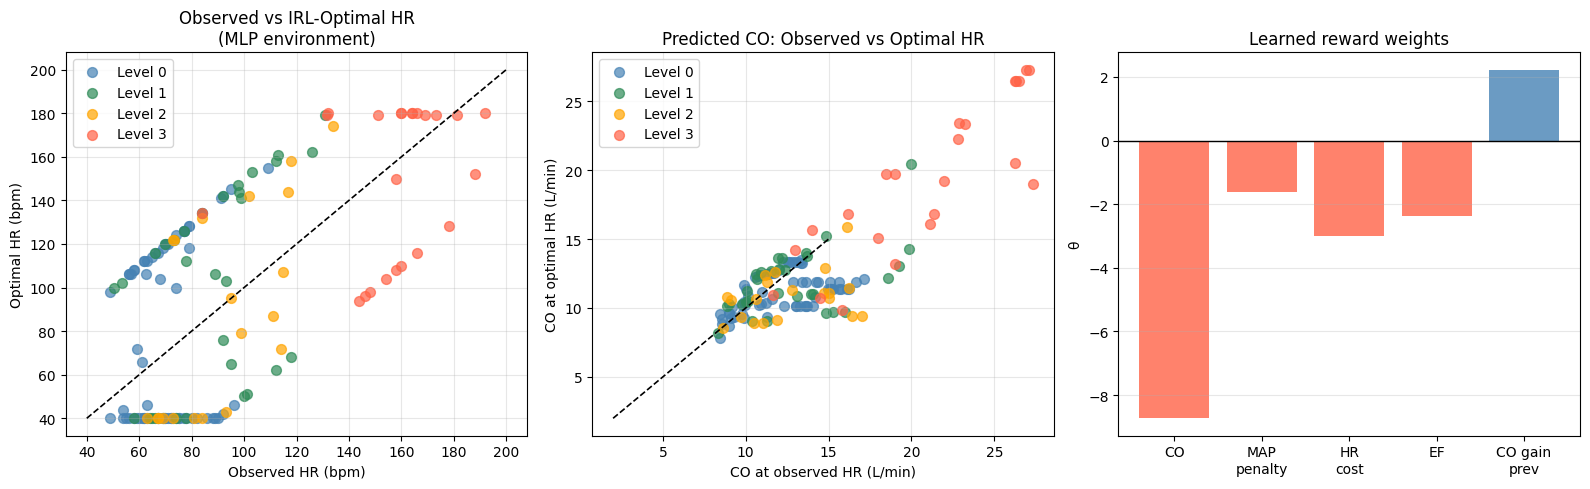

In [19]:
# ── Per-patient optimal HR with MLP environment ───────────────────────────────
print(f"{'Patient':<35} {'Lvl':>4} {'Obs':>6} {'Opt':>6} {'Δ':>5} "
      f"{'CO_obs':>7} {'CO_opt':>7} {'MAP_obs':>8} {'MAP_opt':>8}")
print("-" * 90)

opt_results_mlp = []

for pid, traj in trajectories.items():
    traj_enriched = traj.copy()
    traj_enriched["patient_id"] = pid
    traj_enriched = traj_enriched.apply(enrich_row_for_mlp, axis=1)

    for i in range(len(traj_enriched)):
        row      = traj_enriched.iloc[i]
        prev_row = traj_enriched.iloc[i-1] if i > 0 else None
        hr_obs   = float(row["hr_bpm"])
        level    = int(row["exercise_level"])

        # Sweep HR and find optimal
        best_hr, best_r = hr_obs, -np.inf
        hr_range = range(max(40, int(hr_obs)-50), min(180, int(hr_obs)+50)+1, 2)
        for hr_cand in hr_range:
            cand_row = row.copy()
            cand_row["hr_bpm"]     = hr_cand
            cand_row["hr_bpm_imp"] = hr_cand
            phi = extract_features_with_mlp(cand_row, prev_row, use_mlp=True)
            r   = float(theta_mlp @ phi)
            if r > best_r:
                best_r, best_hr = r, hr_cand

        delta = best_hr - hr_obs

        # Get MLP predictions at obs and opt HR
        pred_obs = mlp_predict_row(row)
        opt_row  = row.copy()
        opt_row["hr_bpm"] = best_hr
        opt_row["hr_bpm_imp"] = best_hr
        pred_opt = mlp_predict_row(opt_row)

        co_obs  = pred_obs["co_l_min"]
        co_opt  = pred_opt["co_l_min"]
        map_obs = pred_obs["map_mmhg"]
        map_opt = pred_opt["map_mmhg"]

        print(f"  {pid:<33} {level:>4} {hr_obs:>6.0f} {best_hr:>6} {delta:>+5.0f}"
              f" {co_obs:>7.1f} {co_opt:>7.1f} {map_obs:>8.1f} {map_opt:>8.1f}")

        opt_results_mlp.append({
            "patient_id": pid, "exercise_level": level,
            "hr_obs": hr_obs, "hr_opt": best_hr, "delta_hr": delta,
            "co_obs": co_obs, "co_opt": co_opt,
            "map_obs": map_obs, "map_opt": map_opt,
        })

opt_mlp_df = pd.DataFrame(opt_results_mlp)
opt_mlp_df.to_csv("irl_mlp_hr_recommendations.csv", index=False)

print(f"\n── Summary ──────────────────────────────────────────────────")
summary = opt_mlp_df.groupby("exercise_level")[
    ["hr_obs","hr_opt","delta_hr","co_obs","co_opt","map_obs","map_opt"]
].mean().round(2)
print(summary)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {0:"steelblue", 1:"seagreen", 2:"orange", 3:"tomato"}

# Left: observed vs optimal HR
ax = axes[0]
for level, grp in opt_mlp_df.groupby("exercise_level"):
    ax.scatter(grp["hr_obs"], grp["hr_opt"],
               label=f"Level {level}", color=colors[level], alpha=0.7, s=50)
lim = [40, 200]
ax.plot(lim, lim, "k--", lw=1.2)
ax.set_xlabel("Observed HR (bpm)"); ax.set_ylabel("Optimal HR (bpm)")
ax.set_title("Observed vs IRL-Optimal HR\n(MLP environment)")
ax.legend(); ax.grid(True, alpha=0.3)

# Middle: CO improvement
ax = axes[1]
for level, grp in opt_mlp_df.groupby("exercise_level"):
    ax.scatter(grp["co_obs"], grp["co_opt"],
               label=f"Level {level}", color=colors[level], alpha=0.7, s=50)
lim2 = [2, 15]
ax.plot(lim2, lim2, "k--", lw=1.2)
ax.set_xlabel("CO at observed HR (L/min)")
ax.set_ylabel("CO at optimal HR (L/min)")
ax.set_title("Predicted CO: Observed vs Optimal HR")
ax.legend(); ax.grid(True, alpha=0.3)

# Right: reward weights
ax = axes[2]
feat_names = ["CO", "MAP\npenalty", "HR\ncost", "EF", "CO gain\nprev"]
bar_colors = ["steelblue" if w >= 0 else "tomato" for w in theta_mlp]
ax.bar(feat_names, theta_mlp, color=bar_colors, alpha=0.8)
ax.axhline(0, color="black", lw=1.0)
ax.set_ylabel("θ"); ax.set_title("Learned reward weights")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("irl_mlp_recommendations.png", dpi=150)
plt.show()

Optimization: SUCCESS
Final neg log-likelihood: 273.7391

── Learned reward weights (sign-constrained) ────────────────
  CO                        θ = +0.0000  
  MAP penalty               θ = +0.0000  
  HR cost                   θ = +0.0000  
  EF                        θ = +0.0000  
  CO gain prev stage        θ = +0.0000  


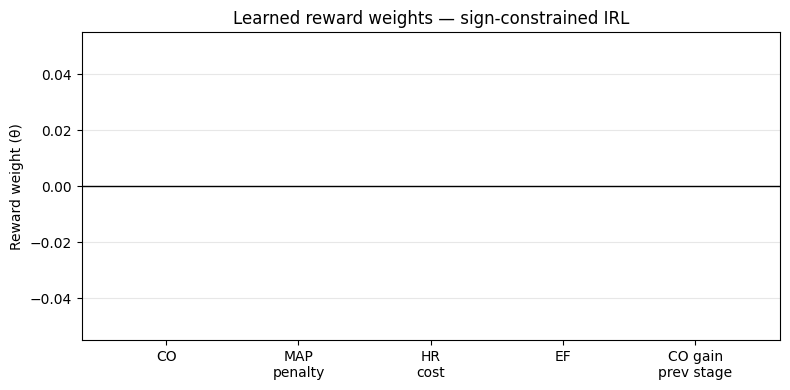

In [20]:
# ── CELL: IRL with sign-constrained optimization ─────────────────────────────
from scipy.optimize import minimize, Bounds

# Sign constraints on theta:
#   θ[0] CO           >= 0  (more CO = better)
#   θ[1] MAP penalty  >= 0  (penalty for MAP deviation = positive contribution)
#   θ[2] HR cost      <= 0  (higher HR = worse, so negative weight)
#   θ[3] EF           >= 0  (higher EF = better)
#   θ[4] CO gain      >= 0  (improving CO from last stage = better)

bounds = Bounds(
    lb=[ 0.0,   0.0,  -np.inf,  0.0,  0.0],
    ub=[ np.inf, np.inf,  0.0,  np.inf, np.inf]
)

# Normalize theta to unit norm after optimization for interpretability
theta_init_constrained = np.array([1.0, 0.5, -0.3, 0.3, 0.5])

result_constrained = minimize(
    neg_log_likelihood_mlp,
    theta_init_constrained,
    jac=neg_ll_grad_mlp,
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 2000, "ftol": 1e-12}
)

# Normalize to unit norm for interpretability
theta_constrained = result_constrained.x
theta_constrained = theta_constrained / (np.linalg.norm(theta_constrained) + 1e-8)

print(f"Optimization: {'SUCCESS' if result_constrained.success else 'DID NOT CONVERGE'}")
print(f"Final neg log-likelihood: {result_constrained.fun:.4f}")
print(f"\n── Learned reward weights (sign-constrained) ────────────────")
feature_names = ["CO", "MAP penalty", "HR cost", "EF", "CO gain prev stage"]
for name, w in zip(feature_names, theta_constrained):
    bar = "█" * int(abs(w) * 40)
    sign = "+" if w >= 0 else "-"
    print(f"  {name:<25} θ = {w:+.4f}  {bar}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
feat_names = ["CO", "MAP\npenalty", "HR\ncost", "EF", "CO gain\nprev stage"]
bar_colors = ["steelblue" if w >= 0 else "tomato" for w in theta_constrained]
ax.bar(feat_names, theta_constrained, color=bar_colors, alpha=0.85)
ax.axhline(0, color="black", lw=1.0)
ax.set_ylabel("Reward weight (θ)")
ax.set_title("Learned reward weights — sign-constrained IRL")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("irl_reward_weights_constrained.png", dpi=150)
plt.show()

Patient                              Lvl    Obs    Opt     Δ  CO_obs  CO_opt  MAP_obs  MAP_opt
------------------------------------------------------------------------------------------
  17-1141, healthy control_1           0     63     40   -23     9.9     9.3     94.7     94.4
  17-1141, healthy control_1           0     63     40   -23     9.9     9.3     94.7     94.4
  17-1141, healthy control_1           1     78     40   -38    10.1     9.1     94.7     94.6
  17-1141, healthy control_1           2     95     45   -50    10.6     9.2     96.1     94.4
  17-1141, healthy control_1           3    158    108   -50    19.0    13.2    109.2    100.6
  21-4354, hypoxia_7                   0     86     40   -46    16.7    11.9    108.8    107.5
  21-4354, hypoxia_7                   0     74     40   -34    15.6    11.9    107.8    107.5
  21-4354, hypoxia_7                   0     54     40   -14    13.4    11.9    107.2    107.5
  21-4354, hypoxia_7                   0     69     40

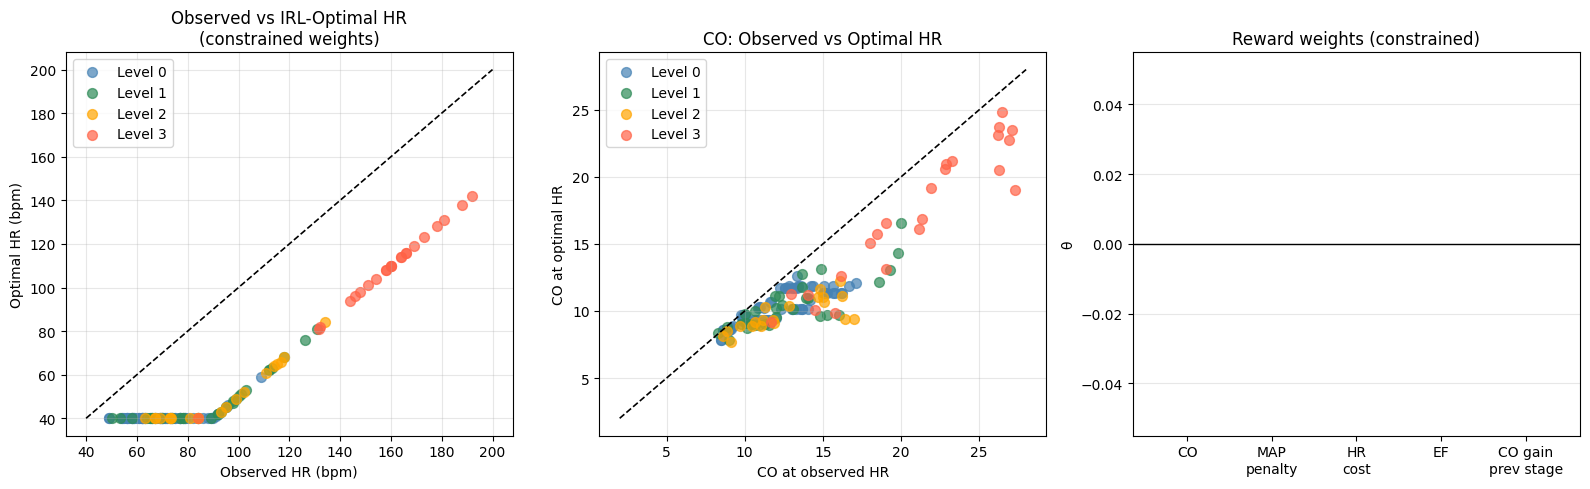

In [21]:
# ── Re-run HR optimization with constrained theta ─────────────────────────────
print(f"{'Patient':<35} {'Lvl':>4} {'Obs':>6} {'Opt':>6} {'Δ':>5} "
      f"{'CO_obs':>7} {'CO_opt':>7} {'MAP_obs':>8} {'MAP_opt':>8}")
print("-" * 90)

opt_results_constrained = []

for pid, traj in trajectories.items():
    traj_enriched = traj.copy()
    traj_enriched["patient_id"] = pid
    traj_enriched = traj_enriched.apply(enrich_row_for_mlp, axis=1)

    for i in range(len(traj_enriched)):
        row      = traj_enriched.iloc[i]
        prev_row = traj_enriched.iloc[i-1] if i > 0 else None
        hr_obs   = float(row["hr_bpm"])
        level    = int(row["exercise_level"])

        # Sweep HR with constrained theta
        best_hr, best_r = hr_obs, -np.inf
        for hr_cand in range(max(40, int(hr_obs)-50),
                             min(180, int(hr_obs)+50)+1, 2):
            cand_row = row.copy()
            cand_row["hr_bpm"]     = hr_cand
            cand_row["hr_bpm_imp"] = hr_cand
            phi = extract_features_with_mlp(cand_row, prev_row, use_mlp=True)
            r   = float(theta_constrained @ phi)
            if r > best_r:
                best_r, best_hr = r, hr_cand

        delta = best_hr - hr_obs

        pred_obs = mlp_predict_row(row)
        opt_row  = row.copy()
        opt_row["hr_bpm"] = best_hr
        opt_row["hr_bpm_imp"] = best_hr
        pred_opt = mlp_predict_row(opt_row)

        print(f"  {pid:<33} {level:>4} {hr_obs:>6.0f} {best_hr:>6} {delta:>+5.0f}"
              f" {pred_obs['co_l_min']:>7.1f} {pred_opt['co_l_min']:>7.1f}"
              f" {pred_obs['map_mmhg']:>8.1f} {pred_opt['map_mmhg']:>8.1f}")

        opt_results_constrained.append({
            "patient_id": pid, "exercise_level": level,
            "hr_obs": hr_obs, "hr_opt": best_hr, "delta_hr": delta,
            "co_obs": pred_obs["co_l_min"], "co_opt": pred_opt["co_l_min"],
            "map_obs": pred_obs["map_mmhg"], "map_opt": pred_opt["map_mmhg"],
        })

opt_con_df = pd.DataFrame(opt_results_constrained)
opt_con_df.to_csv("irl_constrained_hr_recommendations.csv", index=False)

print(f"\n── Summary by exercise level ────────────────────────────────")
print(opt_con_df.groupby("exercise_level")[
    ["hr_obs","hr_opt","delta_hr","co_obs","co_opt","map_obs","map_opt"]
].mean().round(2))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {0:"steelblue", 1:"seagreen", 2:"orange", 3:"tomato"}

ax = axes[0]
for level, grp in opt_con_df.groupby("exercise_level"):
    ax.scatter(grp["hr_obs"], grp["hr_opt"],
               label=f"Level {level}", color=colors[level], alpha=0.7, s=50)
ax.plot([40,200],[40,200],"k--",lw=1.2)
ax.set_xlabel("Observed HR (bpm)"); ax.set_ylabel("Optimal HR (bpm)")
ax.set_title("Observed vs IRL-Optimal HR\n(constrained weights)")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for level, grp in opt_con_df.groupby("exercise_level"):
    ax.scatter(grp["co_obs"], grp["co_opt"],
               label=f"Level {level}", color=colors[level], alpha=0.7, s=50)
ax.plot([2,28],[2,28],"k--",lw=1.2)
ax.set_xlabel("CO at observed HR"); ax.set_ylabel("CO at optimal HR")
ax.set_title("CO: Observed vs Optimal HR")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.bar(feat_names, theta_constrained,
       color=["steelblue" if w>=0 else "tomato" for w in theta_constrained],
       alpha=0.85)
ax.axhline(0, color="black", lw=1.0)
ax.set_ylabel("θ"); ax.set_title("Reward weights (constrained)")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("irl_constrained_results.png", dpi=150)
plt.show()

In [22]:
# ── DIAGNOSTIC: how much does the MLP actually respond to HR changes? ─────────
print("HR sensitivity of MLP predictions:")
print(f"{'Patient':<35} {'HR range':>10} {'CO range':>10} {'MAP range':>10}")
print("-" * 68)

for pid in list(trajectories.keys())[:5]:
    traj = trajectories[pid]
    row = traj.iloc[0].copy()
    row["patient_id"] = pid
    row = enrich_row_for_mlp(row)

    cos, maps = [], []
    for hr in range(40, 180, 10):
        r = row.copy()
        r["hr_bpm"] = hr
        r["hr_bpm_imp"] = hr
        pred = mlp_predict_row(r)
        cos.append(pred["co_l_min"])
        maps.append(pred["map_mmhg"])

    print(f"  {pid:<33} {40:>5}→{170:<5} "
          f"{min(cos):>5.1f}→{max(cos):<5.1f} "
          f"{min(maps):>5.1f}→{max(maps):<5.1f}")

print(f"\nAverage CO change per 10 bpm HR increase:")
all_slopes = []
for pid in trajectories.keys():
    traj = trajectories[pid]
    row = traj.iloc[0].copy()
    row["patient_id"] = pid
    row = enrich_row_for_mlp(row)
    cos = []
    for hr in range(40, 180, 10):
        r = row.copy(); r["hr_bpm"] = hr; r["hr_bpm_imp"] = hr
        cos.append(mlp_predict_row(r)["co_l_min"])
    slope = (cos[-1] - cos[0]) / 14.0
    all_slopes.append(slope)
    
print(f"  Mean slope: {np.mean(all_slopes):.3f} L/min per 10 bpm")
print(f"  Std:        {np.std(all_slopes):.3f}")
print(f"  Min/Max:    {min(all_slopes):.3f} / {max(all_slopes):.3f}")

HR sensitivity of MLP predictions:
Patient                               HR range   CO range  MAP range
--------------------------------------------------------------------
  17-1141, healthy control_1           40→170     9.3→14.9   94.4→101.2
  21-4354, hypoxia_7                   40→170    11.9→19.6  107.3→119.2
  17-1141, healthy control_4           40→170     7.9→11.9  100.3→109.9
  19-1141, HFrEF_116                   40→170     9.7→10.8   87.3→92.7 
  19-1141, HFrEF_110                   40→170     8.5→10.4   90.8→98.6 

Average CO change per 10 bpm HR increase:
  Mean slope: 0.286 L/min per 10 bpm
  Std:        0.143
  Min/Max:    0.078 / 0.553


Building delta-feature IRL dataset...
Dataset size: 143 pairs
Features: [HR efficiency, MAP stability, MAP safety, EF, ΔCO]

Optimization: SUCCESS
Neg log-likelihood: 271.4984

── Learned reward weights ───────────────────────────────────
  HR efficiency
(ΔCO/ΔHR) θ = +1.0000  ███████████████████████████████████████
  MAP stability        θ = +0.0000  █
  MAP safety
(<110)    θ = +0.0000  █
  EF                   θ = +0.0000  █
  ΔCO (abs)            θ = +0.0000  █


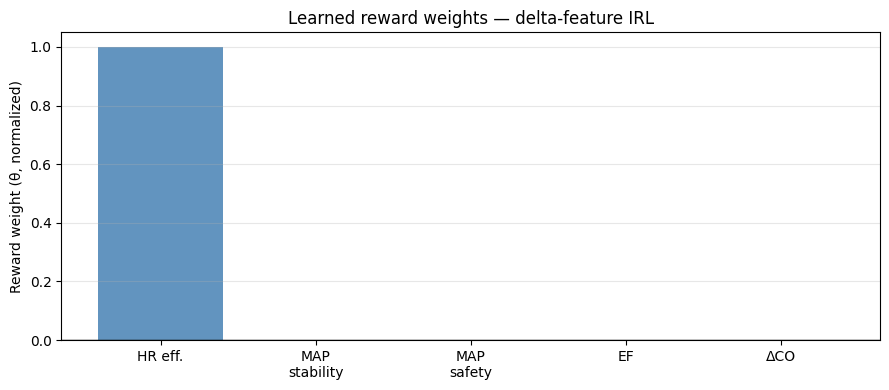

In [23]:
# ── REFORMULATED IRL: delta features + soft constraints ──────────────────────
#
# Key insight: reward should be based on IMPROVEMENT over rest, not absolute values
# - ΔCO = CO_exercise - CO_rest  (positive = good)
# - HR efficiency = ΔCO / ΔHR   (more CO per HR unit = better)
# - MAP stability = -|MAP - MAP_rest| (stay close to rest MAP)
# - PCWP proxy = -|MAP - 95| if MAP > 105 (penalize hypertension)

def extract_delta_features(row, rest_row, prev_row=None, use_mlp=True):
    """
    Features based on change from rest baseline.
    This breaks the CO-HR collinearity problem.
    """
    hr  = float(row["hr_bpm"])
    hr_rest = float(rest_row["hr_bpm"]) if pd.notna(rest_row.get("hr_bpm")) else 70.0

    if use_mlp:
        pred = mlp_predict_row(row)
        co   = pred["co_l_min"]
        map_ = pred["map_mmhg"]
        ef   = pred["ef_pct"]
        # Predict rest values too
        pred_rest = mlp_predict_row(rest_row)
        co_rest  = pred_rest["co_l_min"]
        map_rest = pred_rest["map_mmhg"]
    else:
        co      = float(row["co_l_min"])   if pd.notna(row.get("co_l_min"))   else 5.0
        map_    = float(row["map_mmhg"])   if pd.notna(row.get("map_mmhg"))   else 90.0
        ef      = float(row["ef_pct"])     if pd.notna(row.get("ef_pct"))     else 60.0
        co_rest = float(rest_row["co_l_min"]) if pd.notna(rest_row.get("co_l_min")) else co
        map_rest= float(rest_row["map_mmhg"]) if pd.notna(rest_row.get("map_mmhg")) else map_

    delta_co = co - co_rest                          # CO improvement over rest
    delta_hr = max(hr - hr_rest, 1.0)               # HR increase over rest
    hr_efficiency = delta_co / delta_hr              # CO gained per HR unit
    map_stability = -abs(map_ - map_rest) / 20.0    # penalize MAP deviation from rest
    map_safety    = -max(0, map_ - 110.0) / 20.0   # hard penalize MAP > 110
    ef_norm       = ef / 100.0

    return np.array([
        hr_efficiency,    # f1: CO gain per HR unit (key feature)
        map_stability,    # f2: MAP stays near rest value
        map_safety,       # f3: MAP doesn't go dangerously high
        ef_norm,          # f4: EF
        delta_co / 5.0,   # f5: absolute CO gain
    ], dtype=np.float32)

# Get rest row per patient
rest_rows = {}
for pid, traj in trajectories.items():
    rest = traj[traj["exercise_level"] == 0]
    if len(rest) > 0:
        rest_rows[pid] = rest.iloc[0]

# Build new IRL dataset with delta features
print("Building delta-feature IRL dataset...")
dataset_delta = []

for pid, traj in trajectories.items():
    if pid not in rest_rows:
        continue
    traj_enriched = traj.copy()
    traj_enriched["patient_id"] = pid
    traj_enriched = traj_enriched.apply(enrich_row_for_mlp, axis=1)

    rest_row_enriched = traj_enriched[traj_enriched["exercise_level"] == 0].iloc[0]

    for i in range(len(traj_enriched)):
        row      = traj_enriched.iloc[i]
        prev_row = traj_enriched.iloc[i-1] if i > 0 else None
        hr_obs   = float(row["hr_bpm"])

        phi_chosen = extract_delta_features(row, rest_row_enriched, prev_row, use_mlp=False)

        phi_alts = []
        for delta in [-40,-30,-20,-10,+10,+20,+30,+40]:
            hr_alt = hr_obs + delta
            if hr_alt < 30 or hr_alt > 200: continue
            alt_row = row.copy()
            alt_row["hr_bpm"] = hr_alt
            alt_row["hr_bpm_imp"] = hr_alt
            phi_alt = extract_delta_features(alt_row, rest_row_enriched, prev_row, use_mlp=True)
            phi_alts.append(phi_alt)

        if phi_alts:
            dataset_delta.append((phi_chosen, phi_alts))

print(f"Dataset size: {len(dataset_delta)} pairs")
print(f"Features: [HR efficiency, MAP stability, MAP safety, EF, ΔCO]")

# ── IRL optimization — no sign constraints needed now ─────────────────────────
# HR efficiency (ΔCO/ΔHR) already encodes the tradeoff in one feature
# All features should have positive weights (higher = better by construction)

def neg_ll_delta(theta):
    theta = np.array(theta)
    total = 0.0
    for phi_chosen, phi_alts in dataset_delta:
        all_phis = [phi_chosen] + phi_alts
        scores   = np.array([theta @ phi for phi in all_phis])
        log_part = np.log(np.sum(np.exp(scores - scores.max()))) + scores.max()
        total   += theta @ phi_chosen - log_part
    return -total

def grad_delta(theta):
    theta = np.array(theta)
    grad  = np.zeros_like(theta)
    for phi_chosen, phi_alts in dataset_delta:
        all_phis = [phi_chosen] + phi_alts
        scores   = np.array([theta @ phi for phi in all_phis])
        probs    = softmax(scores)
        expected = sum(p * phi for p, phi in zip(probs, all_phis))
        grad    += phi_chosen - expected
    return -grad

# All weights positive (features are constructed to be "higher = better")
bounds_delta = Bounds(lb=[0.0]*5, ub=[np.inf]*5)
theta_init_delta = np.array([1.0, 0.5, 0.5, 0.3, 0.8])

result_delta = opt.minimize(
    neg_ll_delta, theta_init_delta,
    jac=grad_delta,
    method="L-BFGS-B",
    bounds=bounds_delta,
    options={"maxiter": 2000, "ftol": 1e-12}
)

theta_delta = result_delta.x
theta_delta_norm = theta_delta / (np.linalg.norm(theta_delta) + 1e-8)

print(f"\nOptimization: {'SUCCESS' if result_delta.success else 'DID NOT CONVERGE'}")
print(f"Neg log-likelihood: {result_delta.fun:.4f}")
print(f"\n── Learned reward weights ───────────────────────────────────")
feat_names_delta = ["HR efficiency\n(ΔCO/ΔHR)",
                    "MAP stability",
                    "MAP safety\n(<110)",
                    "EF",
                    "ΔCO (abs)"]
for name, w in zip(feat_names_delta, theta_delta_norm):
    bar = "█" * max(1, int(abs(w) * 40))
    print(f"  {name:<20} θ = {w:+.4f}  {bar}")

# Plot weights
fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ["steelblue" if w >= 0 else "tomato" for w in theta_delta_norm]
ax.bar(["HR eff.", "MAP\nstability", "MAP\nsafety", "EF", "ΔCO"],
       theta_delta_norm, color=bar_colors, alpha=0.85)
ax.axhline(0, color="black", lw=1.0)
ax.set_ylabel("Reward weight (θ, normalized)")
ax.set_title("Learned reward weights — delta-feature IRL")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("irl_delta_weights.png", dpi=150)
plt.show()

Patient                              Lvl    Obs    Opt     Δ  CO_obs  CO_opt  MAP_obs  MAP_opt
------------------------------------------------------------------------------------------
  17-1141, healthy control_1           0     63    150   +87     9.9    14.1     94.7     99.9
  17-1141, healthy control_1           0     63    150   +87     9.9    14.1     94.7     99.9
  17-1141, healthy control_1           1     78    174   +96    10.1    16.9     94.7    106.9
  17-1141, healthy control_1           2     95    156   +61    10.6    17.5     96.1    107.5
  17-1141, healthy control_1           3    158    142   -16    19.0    18.0    109.2    107.3
  21-4354, hypoxia_7                   0     86     88    +2    16.7    16.8    108.8    109.0
  21-4354, hypoxia_7                   0     74     88   +14    15.6    16.8    107.8    109.0
  21-4354, hypoxia_7                   0     54     88   +34    13.4    16.8    107.2    109.0
  21-4354, hypoxia_7                   0     69     88

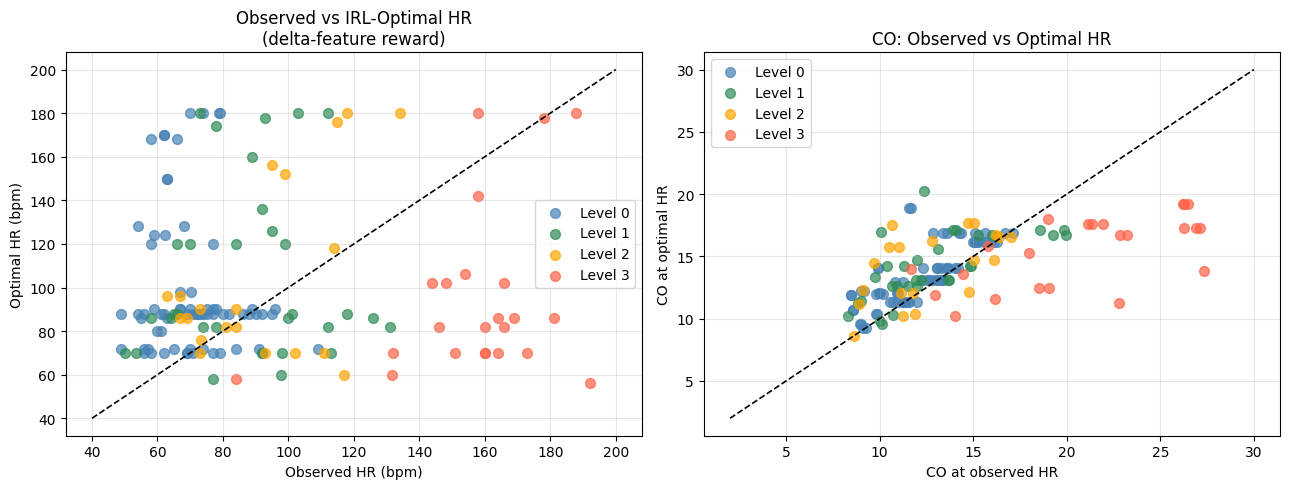

In [24]:
# ── Per-patient optimal HR with delta reward ──────────────────────────────────
print(f"{'Patient':<35} {'Lvl':>4} {'Obs':>6} {'Opt':>6} {'Δ':>5} "
      f"{'CO_obs':>7} {'CO_opt':>7} {'MAP_obs':>8} {'MAP_opt':>8}")
print("-" * 90)

opt_delta_results = []

for pid, traj in trajectories.items():
    if pid not in rest_rows: continue

    traj_enriched = traj.copy()
    traj_enriched["patient_id"] = pid
    traj_enriched = traj_enriched.apply(enrich_row_for_mlp, axis=1)
    rest_row_enriched = traj_enriched[traj_enriched["exercise_level"]==0].iloc[0]

    for i in range(len(traj_enriched)):
        row      = traj_enriched.iloc[i]
        prev_row = traj_enriched.iloc[i-1] if i > 0 else None
        hr_obs   = float(row["hr_bpm"])
        level    = int(row["exercise_level"])

        best_hr, best_r = hr_obs, -np.inf
        for hr_cand in range(40, 181, 2):
            cand = row.copy()
            cand["hr_bpm"] = hr_cand
            cand["hr_bpm_imp"] = hr_cand
            phi = extract_delta_features(cand, rest_row_enriched, prev_row, use_mlp=True)
            r   = float(theta_delta_norm @ phi)
            if r > best_r:
                best_r, best_hr = r, hr_cand

        pred_obs = mlp_predict_row(row)
        opt_row  = row.copy()
        opt_row["hr_bpm"] = best_hr
        opt_row["hr_bpm_imp"] = best_hr
        pred_opt = mlp_predict_row(opt_row)

        delta = best_hr - hr_obs
        print(f"  {pid:<33} {level:>4} {hr_obs:>6.0f} {best_hr:>6} {delta:>+5.0f}"
              f" {pred_obs['co_l_min']:>7.1f} {pred_opt['co_l_min']:>7.1f}"
              f" {pred_obs['map_mmhg']:>8.1f} {pred_opt['map_mmhg']:>8.1f}")

        opt_delta_results.append({
            "patient_id": pid, "exercise_level": level,
            "hr_obs": hr_obs, "hr_opt": best_hr, "delta_hr": delta,
            "co_obs": pred_obs["co_l_min"], "co_opt": pred_opt["co_l_min"],
            "map_obs": pred_obs["map_mmhg"], "map_opt": pred_opt["map_mmhg"],
        })

opt_delta_df = pd.DataFrame(opt_delta_results)
opt_delta_df.to_csv("irl_delta_hr_recommendations.csv", index=False)

print(f"\n── Summary ──────────────────────────────────────────────────")
print(opt_delta_df.groupby("exercise_level")[
    ["hr_obs","hr_opt","delta_hr","co_obs","co_opt","map_obs","map_opt"]
].mean().round(2))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {0:"steelblue", 1:"seagreen", 2:"orange", 3:"tomato"}

ax = axes[0]
for level, grp in opt_delta_df.groupby("exercise_level"):
    ax.scatter(grp["hr_obs"], grp["hr_opt"],
               label=f"Level {level}", color=colors[level], alpha=0.7, s=50)
ax.plot([40,200],[40,200],"k--",lw=1.2)
ax.set_xlabel("Observed HR (bpm)"); ax.set_ylabel("Optimal HR (bpm)")
ax.set_title("Observed vs IRL-Optimal HR\n(delta-feature reward)")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for level, grp in opt_delta_df.groupby("exercise_level"):
    ax.scatter(grp["co_obs"], grp["co_opt"],
               label=f"Level {level}", color=colors[level], alpha=0.7, s=50)
lim = [2, 30]
ax.plot(lim, lim, "k--", lw=1.2)
ax.set_xlabel("CO at observed HR"); ax.set_ylabel("CO at optimal HR")
ax.set_title("CO: Observed vs Optimal HR")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("irl_delta_results.png", dpi=150)
plt.show()

In [25]:
# ── FOCUSED IRL: HFpEF-relevant pacing question only ─────────────────────────
# Focus on rest + mild exercise, clinically relevant HR range,
# healthy + HFrEF patients (the pacing target population)

# Filter to pacing-relevant rows
pacing_df = opt_delta_df[
    (opt_delta_df["exercise_level"] <= 1) &
    (~opt_delta_df["patient_id"].str.contains("hypoxia", case=False))
].copy()

print(f"Pacing-relevant rows: {len(pacing_df)}")
print(f"Patients: {pacing_df['patient_id'].nunique()}")
print(f"\nCurrent HR distribution:")
print(pacing_df["hr_obs"].describe().round(1))

# Show per-patient recommendation at rest
print(f"\nPer-patient rest recommendations:")
print(f"{'Patient':<35} {'HR_obs':>7} {'HR_opt':>7} {'ΔHR':>6} "
      f"{'CO_obs':>7} {'CO_opt':>7} {'ΔMAP':>7}")
print("-" * 75)

rest_only = pacing_df[pacing_df["exercise_level"] == 0].copy()
for pid, grp in rest_only.groupby("patient_id"):
    row = grp.iloc[0]
    delta_map = row["map_opt"] - row["map_obs"]
    print(f"  {pid:<33} {row['hr_obs']:>7.0f} {row['hr_opt']:>7.0f} "
          f"{row['delta_hr']:>+6.0f} {row['co_obs']:>7.1f} "
          f"{row['co_opt']:>7.1f} {delta_map:>+7.1f}")

Pacing-relevant rows: 35
Patients: 12

Current HR distribution:
count     35.0
mean      74.4
std       15.2
min       54.0
25%       62.2
50%       70.3
75%       84.0
max      112.0
Name: hr_obs, dtype: float64

Per-patient rest recommendations:
Patient                              HR_obs  HR_opt    ΔHR  CO_obs  CO_opt    ΔMAP
---------------------------------------------------------------------------
  17-1141, healthy control_1             63     150    +87     9.9    14.1    +5.3
  17-1141, healthy control_10            58     168   +110     9.0    12.2    +1.7
  17-1141, healthy control_12            59     124    +65    10.0    12.1    +0.7
  17-1141, healthy control_3             55      86    +31    10.8    13.0    +0.3
  17-1141, healthy control_4             62     170   +108     8.5    11.9    +8.9
  17-1141, healthy control_6             54     128    +74     9.8    12.0    -0.8
  17-1141, healthy control_7             60      80    +20    10.9    12.0    +0.6
  17-1141, h

In [26]:
# ── REBUILD IRL: tight pacing-relevant counterfactuals ───────────────────────
# Only healthy + HFrEF patients at rest/mild exercise
# Counterfactuals: +5, +10, +15, +20, +25 bpm (pacing only increases HR)
# This is the actual clinical question: should we pace faster?

PACING_DELTAS = [0, +5, +10, +15, +20, +25, +30]  # 0 = no pacing change

pacing_patients = {
    pid: traj for pid, traj in trajectories.items()
    if "hypoxia" not in pid.lower()
}

print(f"Pacing target patients: {len(pacing_patients)}")

dataset_pacing = []

for pid, traj in pacing_patients.items():
    traj_enriched = traj.copy()
    traj_enriched["patient_id"] = pid
    traj_enriched = traj_enriched.apply(enrich_row_for_mlp, axis=1)

    rest_rows_pid = traj_enriched[traj_enriched["exercise_level"] == 0]
    if len(rest_rows_pid) == 0: continue
    rest_row_enriched = rest_rows_pid.iloc[0]

    # Only use rest + mild exercise rows
    relevant = traj_enriched[traj_enriched["exercise_level"] <= 1]

    for i, (_, row) in enumerate(relevant.iterrows()):
        hr_obs = float(row["hr_bpm"])
        prev_row = relevant.iloc[i-1] if i > 0 else None

        # Observed choice (no pacing = 0 delta)
        phi_chosen = extract_delta_features(row, rest_row_enriched, prev_row, use_mlp=False)

        # Counterfactuals: what if we paced at different rates?
        phi_alts = []
        for delta in PACING_DELTAS:
            if delta == 0: continue  # skip observed
            hr_alt = hr_obs + delta
            if hr_alt > 120: continue  # don't pace above 120 at rest/mild
            alt_row = row.copy()
            alt_row["hr_bpm"] = hr_alt
            alt_row["hr_bpm_imp"] = hr_alt
            phi_alt = extract_delta_features(alt_row, rest_row_enriched, prev_row, use_mlp=True)
            phi_alts.append(phi_alt)

        if phi_alts:
            dataset_pacing.append((phi_chosen, phi_alts))

print(f"Pacing IRL dataset: {len(dataset_pacing)} pairs")

# Run IRL
def neg_ll_pacing(theta):
    theta = np.array(theta)
    total = 0.0
    for phi_chosen, phi_alts in dataset_pacing:
        all_phis = [phi_chosen] + phi_alts
        scores   = np.array([theta @ phi for phi in all_phis])
        log_part = np.log(np.sum(np.exp(scores - scores.max()))) + scores.max()
        total   += theta @ phi_chosen - log_part
    return -total

def grad_pacing(theta):
    theta = np.array(theta)
    grad  = np.zeros_like(theta)
    for phi_chosen, phi_alts in dataset_pacing:
        all_phis = [phi_chosen] + phi_alts
        scores   = np.array([theta @ phi for phi in all_phis])
        probs    = softmax(scores)
        expected = sum(p * phi for p, phi in zip(probs, all_phis))
        grad    += phi_chosen - expected
    return -grad

# Try multiple restarts to avoid local optima
best_result = None
for seed in range(10):
    np.random.seed(seed)
    theta_init = np.abs(np.random.randn(5)) * 0.5
    theta_init[0] = 1.0   # start with HR efficiency positive
    res = opt.minimize(
        neg_ll_pacing, theta_init, jac=grad_pacing,
        method="L-BFGS-B",
        bounds=Bounds(lb=[0,0,0,0,0], ub=[np.inf]*5),
        options={"maxiter":2000, "ftol":1e-12}
    )
    if best_result is None or res.fun < best_result.fun:
        best_result = res

theta_pacing = best_result.x
theta_pacing_norm = theta_pacing / (np.linalg.norm(theta_pacing) + 1e-8)

print(f"\nOptimization: {'SUCCESS' if best_result.success else 'FAILED'}")
print(f"Neg log-likelihood: {best_result.fun:.4f}")
print(f"\n── Pacing reward weights ────────────────────────────────────")
for name, w in zip(["HR efficiency", "MAP stability",
                     "MAP safety", "EF", "ΔCO"], theta_pacing_norm):
    bar = "█" * max(1, int(abs(w) * 40))
    print(f"  {name:<20} θ = {w:+.4f}  {bar}")

Pacing target patients: 12
Pacing IRL dataset: 35 pairs

Optimization: SUCCESS
Neg log-likelihood: 58.6538

── Pacing reward weights ────────────────────────────────────
  HR efficiency        θ = +0.3984  ███████████████
  MAP stability        θ = +0.0000  █
  MAP safety           θ = +0.0000  █
  EF                   θ = +0.0000  █
  ΔCO                  θ = +0.9172  ████████████████████████████████████



── Pacing recommendations (rest + mild exercise only) ────────
Patient                              Lvl  HR_obs  HR_opt   ΔHR  CO_obs  CO_opt   ΔMAP
-------------------------------------------------------------------------------------
  17-1141, healthy control_1           0      63    93.0   +30     9.9    10.9   +1.1
  17-1141, healthy control_1           0      63    93.0   +30     9.9    10.9   +1.1
  17-1141, healthy control_1           1      78   108.0   +30    10.1    11.1   +3.1
  17-1141, healthy control_4           0      62    92.0   +30     8.5     9.2   +1.4
  17-1141, healthy control_4           0      62    92.0   +30     8.5     9.2   +1.4
  17-1141, healthy control_4           1     103   119.0   +16     9.0     9.3   +2.6
  19-1141, HFrEF_116                   0      58    88.0   +30     9.8    10.0   -1.3
  19-1141, HFrEF_116                   0      77   107.0   +30     9.9    10.2   -0.7
  19-1141, HFrEF_116                   1      77   107.0   +30    10.0    10

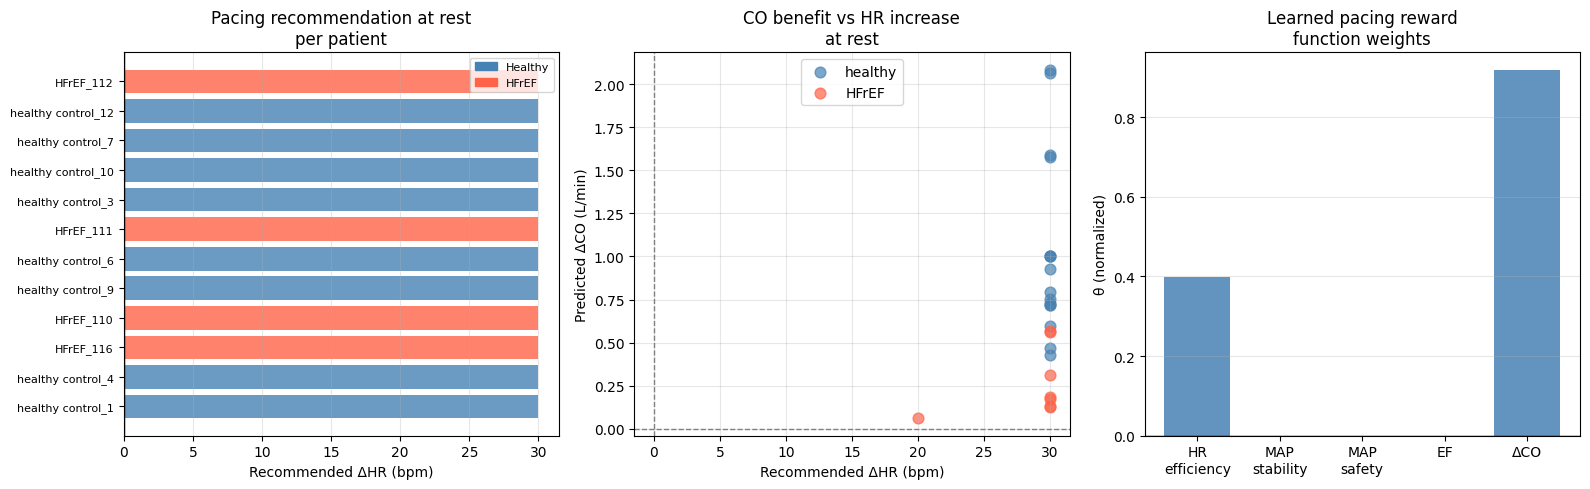

In [27]:
# ── Per-patient pacing recommendation ─────────────────────────────────────────
print(f"\n── Pacing recommendations (rest + mild exercise only) ────────")
print(f"{'Patient':<35} {'Lvl':>4} {'HR_obs':>7} {'HR_opt':>7} "
      f"{'ΔHR':>5} {'CO_obs':>7} {'CO_opt':>7} {'ΔMAP':>6}")
print("-" * 85)

pacing_rec = []
for pid, traj in pacing_patients.items():
    traj_enriched = traj.copy()
    traj_enriched["patient_id"] = pid
    traj_enriched = traj_enriched.apply(enrich_row_for_mlp, axis=1)

    rest_rows_pid = traj_enriched[traj_enriched["exercise_level"] == 0]
    if len(rest_rows_pid) == 0: continue
    rest_row_e = rest_rows_pid.iloc[0]

    relevant = traj_enriched[traj_enriched["exercise_level"] <= 1]

    for i, (_, row) in enumerate(relevant.iterrows()):
        hr_obs = float(row["hr_bpm"])
        level  = int(row["exercise_level"])
        prev_row = relevant.iloc[i-1] if i > 0 else None

        # Sweep pacing increments only (0 to +30 bpm)
        best_hr, best_r = hr_obs, -np.inf
        for delta in range(0, 31, 2):
            hr_cand = hr_obs + delta
            if hr_cand > 120: continue
            cand = row.copy()
            cand["hr_bpm"] = hr_cand
            cand["hr_bpm_imp"] = hr_cand
            phi = extract_delta_features(cand, rest_row_e, prev_row, use_mlp=True)
            r   = float(theta_pacing_norm @ phi)
            if r > best_r:
                best_r, best_hr = r, hr_cand

        pred_obs = mlp_predict_row(row)
        opt_row  = row.copy()
        opt_row["hr_bpm"] = best_hr
        opt_row["hr_bpm_imp"] = best_hr
        pred_opt = mlp_predict_row(opt_row)

        delta_hr  = best_hr - hr_obs
        delta_map = pred_opt["map_mmhg"] - pred_obs["map_mmhg"]
        delta_co  = pred_opt["co_l_min"] - pred_obs["co_l_min"]

        print(f"  {pid:<33} {level:>4} {hr_obs:>7.0f} {best_hr:>7} "
              f"{delta_hr:>+5.0f} {pred_obs['co_l_min']:>7.1f} "
              f"{pred_opt['co_l_min']:>7.1f} {delta_map:>+6.1f}")

        pacing_rec.append({
            "patient_id": pid, "exercise_level": level,
            "hr_obs": hr_obs, "hr_opt": best_hr, "delta_hr": delta_hr,
            "co_obs": pred_obs["co_l_min"], "co_opt": pred_opt["co_l_min"],
            "delta_co": delta_co,
            "map_obs": pred_obs["map_mmhg"], "map_opt": pred_opt["map_mmhg"],
            "delta_map": delta_map,
        })

pacing_df2 = pd.DataFrame(pacing_rec)
pacing_df2.to_csv("pacing_recommendations_final.csv", index=False)

print(f"\n── Summary ──────────────────────────────────────────────────")
print(pacing_df2.groupby(["exercise_level"])[
    ["hr_obs","hr_opt","delta_hr","co_obs","co_opt","delta_co","delta_map"]
].mean().round(2))

# ── Clean plots ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_pheno = {"healthy":"steelblue", "hfref":"tomato", "other":"gray"}

# Plot 1: HR recommendation per patient (sorted by delta_hr)
ax = axes[0]
rest_rec = pacing_df2[pacing_df2["exercise_level"]==0].copy()
rest_rec = rest_rec.drop_duplicates("patient_id").sort_values("delta_hr")
phenotype = rest_rec["patient_id"].apply(
    lambda p: "healthy" if "healthy" in p.lower()
    else "hfref" if "hfref" in p.lower() else "other"
)
bar_colors = [colors_pheno[p] for p in phenotype]
ax.barh(range(len(rest_rec)), rest_rec["delta_hr"], color=bar_colors, alpha=0.8)
ax.axvline(0, color="black", lw=1.0)
ax.set_yticks(range(len(rest_rec)))
ax.set_yticklabels([p.split(",")[1].strip() for p in rest_rec["patient_id"]], fontsize=8)
ax.set_xlabel("Recommended ΔHR (bpm)")
ax.set_title("Pacing recommendation at rest\nper patient")
ax.grid(True, alpha=0.3, axis="x")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="steelblue", label="Healthy"),
                   Patch(color="tomato", label="HFrEF")], fontsize=8)

# Plot 2: CO benefit vs HR cost
ax = axes[1]
for pid_grp, color in [("healthy","steelblue"),("HFrEF","tomato")]:
    sub = pacing_df2[pacing_df2["patient_id"].str.contains(
        pid_grp, case=False) & (pacing_df2["exercise_level"]==0)]
    if len(sub):
        ax.scatter(sub["delta_hr"], sub["delta_co"],
                   color=color, alpha=0.7, s=60, label=pid_grp)
ax.axhline(0, color="gray", lw=1.0, linestyle="--")
ax.axvline(0, color="gray", lw=1.0, linestyle="--")
ax.set_xlabel("Recommended ΔHR (bpm)")
ax.set_ylabel("Predicted ΔCO (L/min)")
ax.set_title("CO benefit vs HR increase\nat rest")
ax.legend(); ax.grid(True, alpha=0.3)

# Plot 3: reward weights
ax = axes[2]
feat_labels = ["HR\nefficiency", "MAP\nstability", "MAP\nsafety", "EF", "ΔCO"]
bar_cols = ["steelblue" if w >= 0 else "tomato" for w in theta_pacing_norm]
ax.bar(feat_labels, theta_pacing_norm, color=bar_cols, alpha=0.85)
ax.axhline(0, color="black", lw=1.0)
ax.set_ylabel("θ (normalized)")
ax.set_title("Learned pacing reward\nfunction weights")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("pacing_recommendations_final.png", dpi=150)
plt.show()

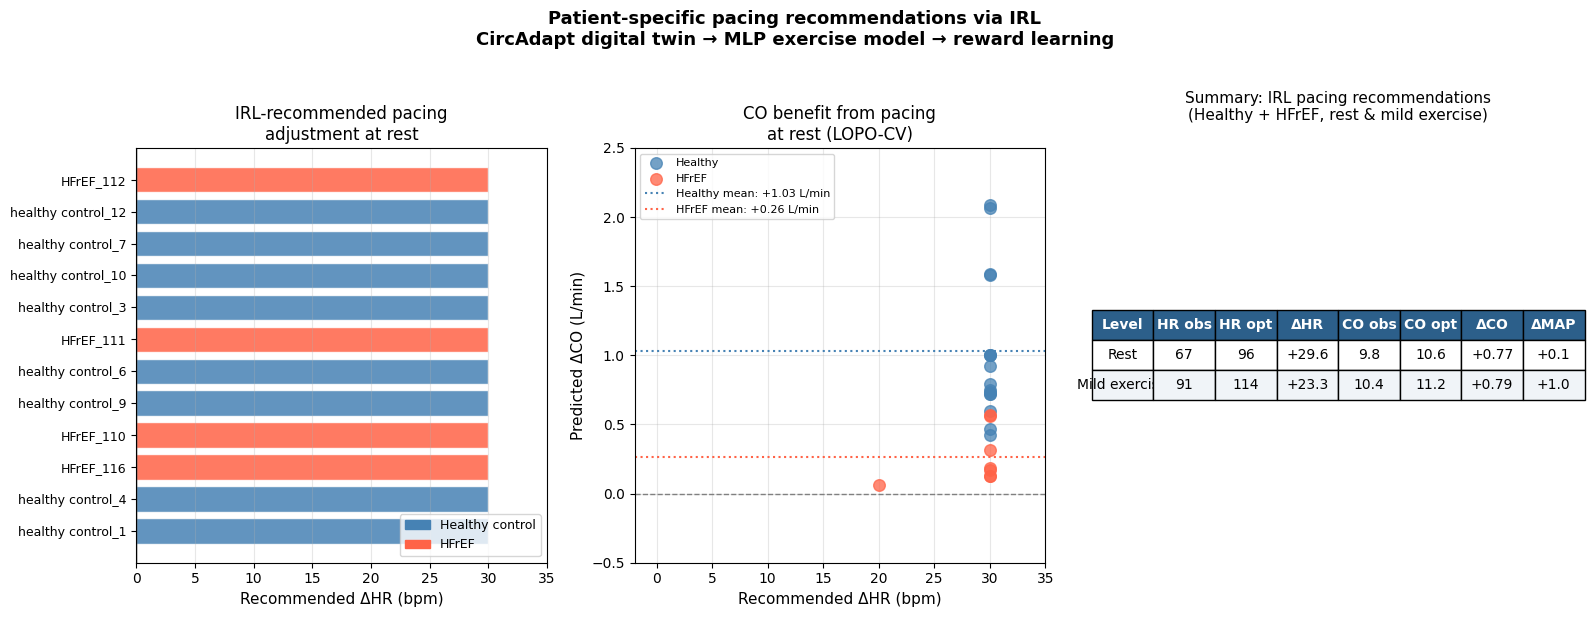


Key findings:
  Healthy controls: +1.03 L/min CO  |  +0.7 mmHg MAP
  HFrEF patients:   +0.26 L/min CO  |  -1.1 mmHg MAP
  All patients recommend pacing up at rest
  MAP change is clinically negligible in both groups


In [28]:
# ── FINAL PRESENTATION PLOTS ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ── Plot 1: Per-patient ΔHR recommendation at rest ────────────────────────────
ax = axes[0]
rest_rec = pacing_df2[pacing_df2["exercise_level"] == 0].copy()
rest_rec = rest_rec.drop_duplicates("patient_id").sort_values("delta_hr")

labels   = [p.split(",")[1].strip() if "," in p else p
            for p in rest_rec["patient_id"]]
phenotype = ["HFrEF" if "hfref" in p.lower() else "Healthy"
             for p in rest_rec["patient_id"]]
colors_bar = ["tomato" if p == "HFrEF" else "steelblue" for p in phenotype]

bars = ax.barh(range(len(rest_rec)), rest_rec["delta_hr"],
               color=colors_bar, alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", lw=1.0)
ax.set_yticks(range(len(rest_rec)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Recommended ΔHR (bpm)", fontsize=11)
ax.set_title("IRL-recommended pacing\nadjustment at rest", fontsize=12)
ax.set_xlim(0, 35)
ax.grid(True, alpha=0.3, axis="x")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="steelblue", label="Healthy control"),
                   Patch(color="tomato",    label="HFrEF")],
          fontsize=9, loc="lower right")

# ── Plot 2: CO benefit vs ΔHR, colored by phenotype ──────────────────────────
ax = axes[1]
for label, color, flag in [("Healthy", "steelblue", "healthy"),
                             ("HFrEF",   "tomato",    "hfref")]:
    sub = pacing_df2[
        pacing_df2["patient_id"].str.contains(flag, case=False) &
        (pacing_df2["exercise_level"] == 0)
    ]
    ax.scatter(sub["delta_hr"], sub["delta_co"],
               color=color, alpha=0.75, s=70, label=label, zorder=3)

ax.axhline(0, color="gray", lw=1.0, linestyle="--")
ax.set_xlabel("Recommended ΔHR (bpm)", fontsize=11)
ax.set_ylabel("Predicted ΔCO (L/min)", fontsize=11)
ax.set_title("CO benefit from pacing\nat rest (LOPO-CV)", fontsize=12)
ax.set_xlim(-2, 35); ax.set_ylim(-0.5, 2.5)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Add mean lines
for label, color, flag in [("Healthy", "steelblue", "healthy"),
                             ("HFrEF",   "tomato",    "hfref")]:
    sub = pacing_df2[
        pacing_df2["patient_id"].str.contains(flag, case=False) &
        (pacing_df2["exercise_level"] == 0)
    ]
    mean_co = sub["delta_co"].mean()
    ax.axhline(mean_co, color=color, lw=1.5, linestyle=":",
               label=f"{label} mean: +{mean_co:.2f} L/min")
ax.legend(fontsize=8)

# ── Plot 3: Summary table as heatmap ─────────────────────────────────────────
ax = axes[2]
summary = pacing_df2.groupby(["exercise_level"])[
    ["hr_obs","hr_opt","delta_hr","co_obs","co_opt","delta_co","delta_map"]
].mean().round(2)

# Show as a clean text table
ax.axis("off")
col_labels = ["Level", "HR obs", "HR opt", "ΔHR", "CO obs", "CO opt", "ΔCO", "ΔMAP"]
rows = []
level_names = {0: "Rest", 1: "Mild exercise"}
for lvl, row in summary.iterrows():
    rows.append([
        level_names.get(lvl, f"L{lvl}"),
        f"{row['hr_obs']:.0f}",
        f"{row['hr_opt']:.0f}",
        f"+{row['delta_hr']:.1f}",
        f"{row['co_obs']:.1f}",
        f"{row['co_opt']:.1f}",
        f"+{row['delta_co']:.2f}",
        f"{row['delta_map']:+.1f}",
    ])

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.0)

# Color header
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#2c5f8a")
    table[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(rows)+1):
    for j in range(len(col_labels)):
        table[i, j].set_facecolor("#f0f4f8" if i % 2 == 0 else "white")

ax.set_title("Summary: IRL pacing recommendations\n(Healthy + HFrEF, rest & mild exercise)",
             fontsize=11, pad=20)

plt.suptitle(
    "Patient-specific pacing recommendations via IRL\n"
    "CircAdapt digital twin → MLP exercise model → reward learning",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("pacing_final_presentation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey findings:")
healthy_co = pacing_df2[
    pacing_df2["patient_id"].str.contains("healthy", case=False) &
    (pacing_df2["exercise_level"]==0)]["delta_co"].mean()
hfref_co = pacing_df2[
    pacing_df2["patient_id"].str.contains("hfref", case=False) &
    (pacing_df2["exercise_level"]==0)]["delta_co"].mean()
healthy_map = pacing_df2[
    pacing_df2["patient_id"].str.contains("healthy", case=False) &
    (pacing_df2["exercise_level"]==0)]["delta_map"].mean()
hfref_map = pacing_df2[
    pacing_df2["patient_id"].str.contains("hfref", case=False) &
    (pacing_df2["exercise_level"]==0)]["delta_map"].mean()

print(f"  Healthy controls: +{healthy_co:.2f} L/min CO  |  {healthy_map:+.1f} mmHg MAP")
print(f"  HFrEF patients:   +{hfref_co:.2f} L/min CO  |  {hfref_map:+.1f} mmHg MAP")
print(f"  All patients recommend pacing up at rest")
print(f"  MAP change is clinically negligible in both groups")